In [35]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.16
culRI-Bayesian


# 1. Workbook setups

## 1.1 Import packages

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time


## 1.2 Miscellaneous codes

In [2]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



### 1.2.1 Pred TEX and Pred SST from previous calibrations

In [3]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(66.6667,-18.6667),
        'schouten2003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten2002':(0.015,0.280),
        'schouten2003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien2017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## 1.3 Dictionaries

In [4]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [5]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/stan_models/'

In [6]:
from cmdstanpy import CmdStanModel

test_model = CmdStanModel(stan_file=os.path.join(stan_models_path,"test_model.stan"), 
                          force_compile=True)
fit = test_model.sample(chains=1, iter_sampling=100, iter_warmup=100, seed=42)


/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
15:21:03 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/stan_models/test_model.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/stan_models/test_model
15:21:10 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/stan_models/test_model
15:21:10 - cmdstanpy - INFO - CmdStan start processing
chain 1 |██████████| 00:00 Sampling completed


15:21:10 - cmdstanpy - INFO - CmdStan done processing.


# 2. Import data

## 2.1 Import Ocean Data Products

In [7]:
fpath2 = fr'{local_documents_path}/Postdoc/TEXAS-PSM/netcdf/WOA-database/WOA23/WOA-decav'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).load()
T_da

<xarray.Dataset>
Dimensions:             (lat: 720, nbounds: 2, lon: 1440, depth: 102)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
Dimensions without coordinates: nbounds
Data variables: (12/14)
    crs                 int32 -2147483647
    lat_bnds            (lat, nbounds) float32 -90.0 -89.75 ... 89.75 90.0
    lon_bnds            (lon, nbounds) float32 -180.0 -179.8 ... 179.8 180.0
    depth_bnds          (depth, nbounds) float32 0.0 2.5 ... 5.45e+03 5.5e+03
    climatology_bounds  (nbounds) float32 1.704e+03 2.064e+03
    t_an                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    ...                  ...
    t_sd                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_se                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_oa                (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_gp                (depth, lat, lon) float64 nan nan nan ... nan nan nan
    t_sdo               (depth, lat, lon) float32 nan nan nan ... nan nan nan
    t_sea               (depth, lat, lon) float32 nan nan nan ... nan nan nan
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [8]:
import glob

fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/monthly'
### read multiple netcdf files
nc_files = sorted(glob.glob(os.path.join(fpath2, '*.nc')))

ds = xr.open_mfdataset(nc_files, decode_times=False, combine='by_coords').drop('time')
## assign month as coordinates from 1 to 12 
ds['month'] = np.arange(1,13)
ds

<xarray.Dataset>
Dimensions:             (time: 12, lat: 720, nbounds: 2, lon: 1440, depth: 57,
                         month: 12)
Coordinates:
  * lat                 (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon                 (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth               (depth) float32 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * month               (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: time, nbounds
Data variables: (12/15)
    crs                 (time) int32 -2147483647 -2147483647 ... -2147483647
    lat_bnds            (time, lat, nbounds) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds            (time, lon, nbounds) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    depth_bnds          (time, depth, nbounds) float32 dask.array<chunksize=(1, 57, 2), meta=np.ndarray>
    climatology_bounds  (time, nbounds) float32 dask.array<chunksize=(1, 2), meta=np.ndarray>
    t_an                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    ...                  ...
    t_se                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_oa                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_ma                (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_gp                (time, depth, lat, lon) float64 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sdo               (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
    t_sea               (time, depth, lat, lon) float32 dask.array<chunksize=(1, 57, 720, 1440), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_tempe...
    summary:                         Climatological mean temperature for the ...
    references:                      Locarnini, R.A., A.V. Mishonov, O.K. Bar...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [9]:
T_diff = ds.t_an.isel(depth=0).max(dim='time') - ds.t_an.isel(depth=0).min(dim='time')
T_max = ds.t_an.isel(depth=0).max(dim='time')
T_min = ds.t_an.isel(depth=0).min(dim='time')

/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/dask/array/reductions.py:655: RuntimeWarning: All-NaN slice encou

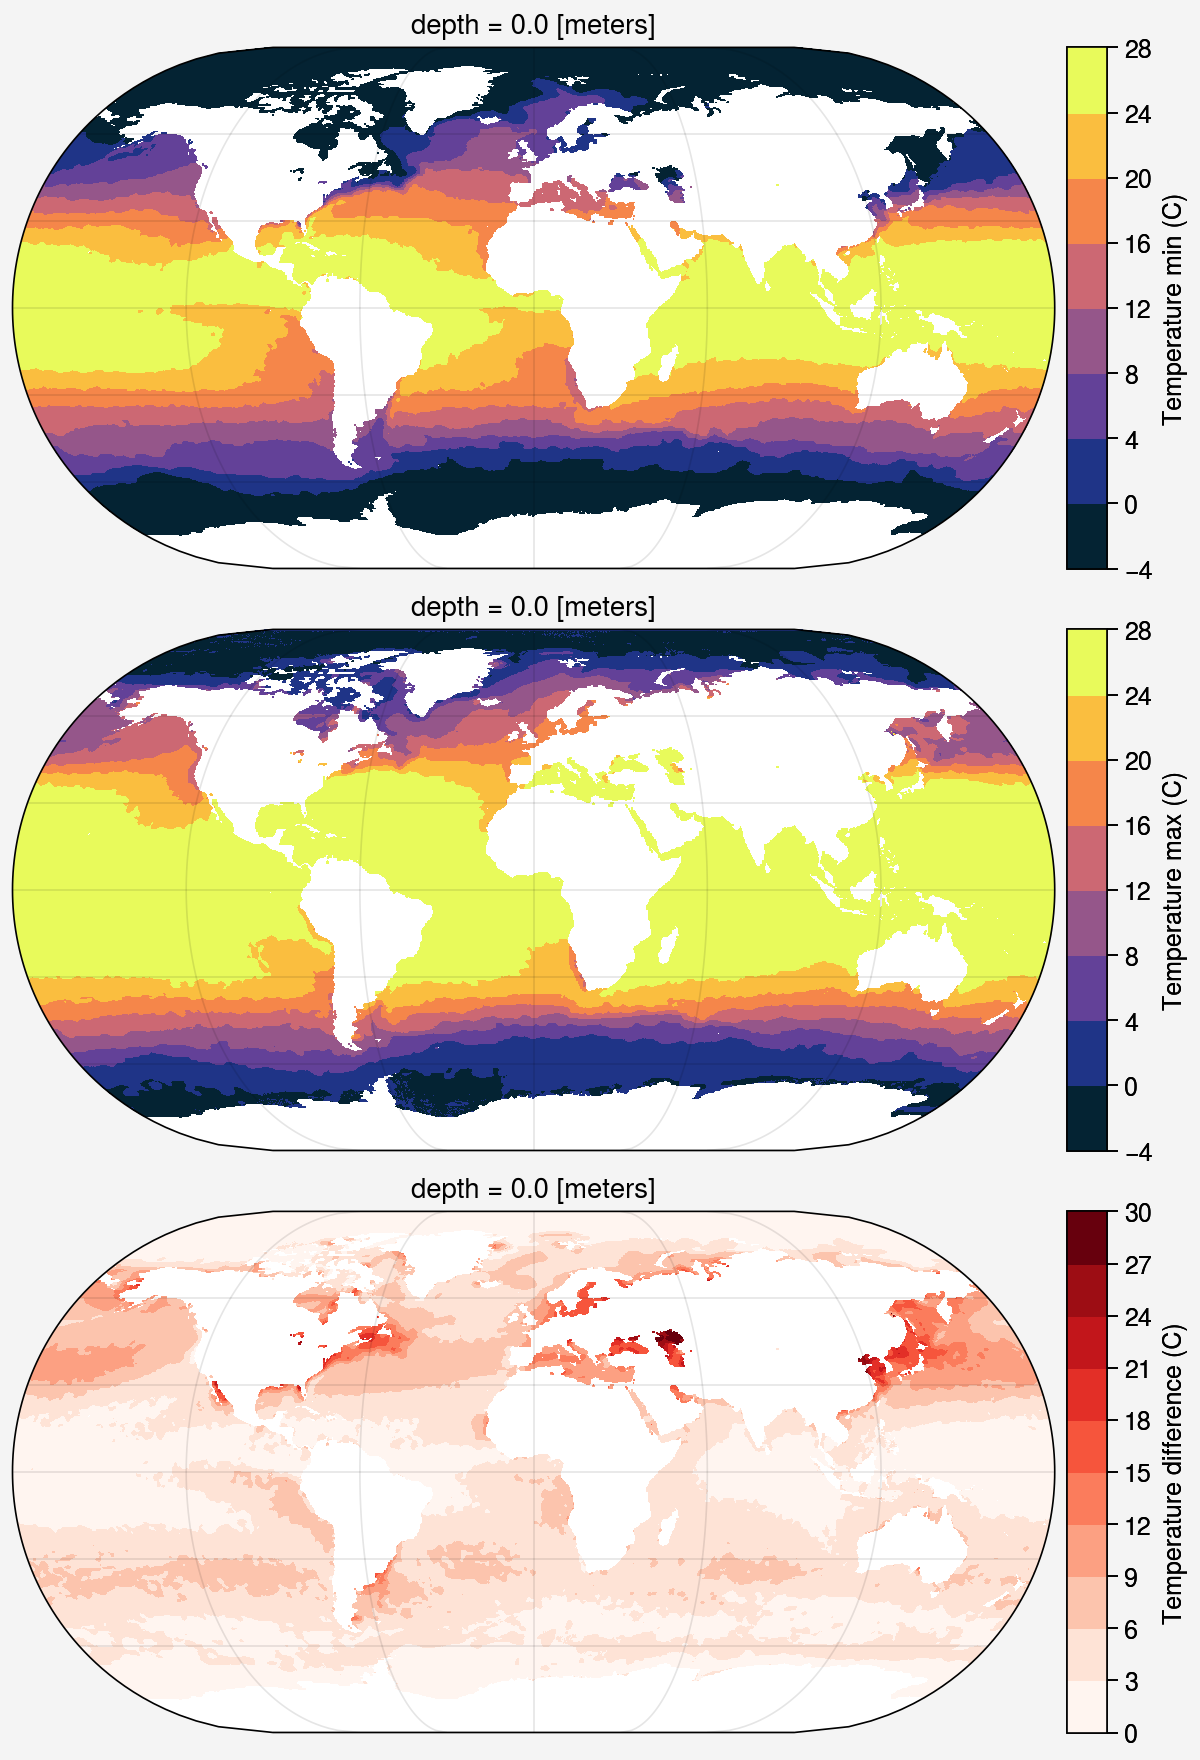

In [10]:
fig, axs = plot.subplots(nrows=3,proj='eck3',width=6)
T_min.plot(ax=axs[0],robust=True,vmin=-4,vmax=30, cmap='cmo.thermal', cbar_kwargs={'label':'Temperature min (C)'})
T_max.plot(ax=axs[1],robust=True,vmin=-4,vmax=30, cmap='cmo.thermal', cbar_kwargs={'label':'Temperature max (C)'})
T_diff.plot(ax=axs[2],robust=True,vmin=0,vmax=30, cmap='reds', cbar_kwargs={'label':'Temperature difference (C)'})

/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/ronnie-rattan/miniforge3/envs/culRI-Bayesian/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` key

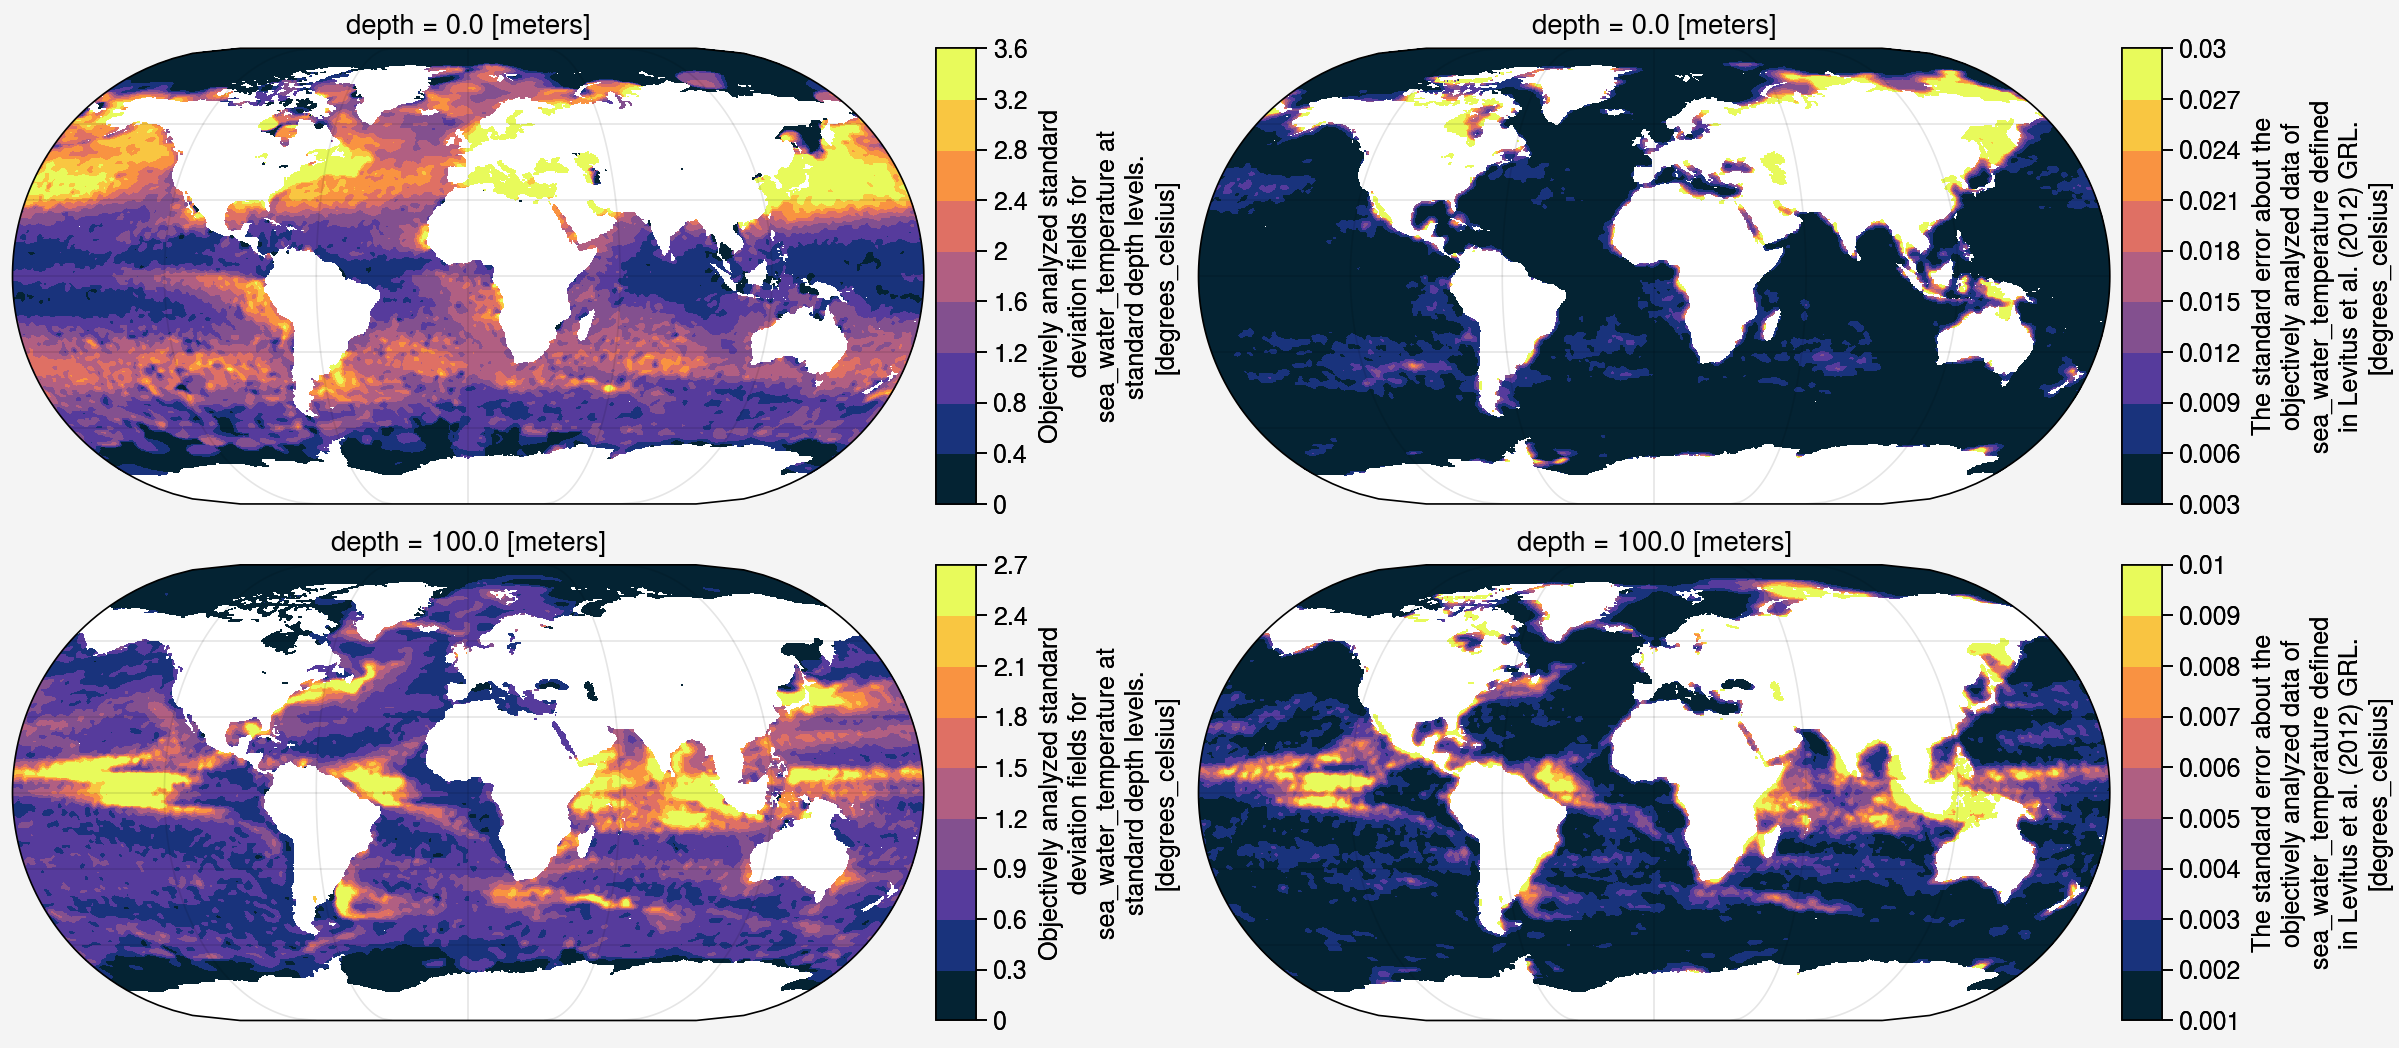

In [11]:
fig, axs = plot.subplots(width=12,proj='eck3',nrows=2,ncols=2)

ax = axs[0,0]
T_da.t_sdo.sel(depth=0,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[0,1]
T_da.t_sea.sel(depth=0,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[1,0]
T_da.t_sdo.sel(depth=100,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

ax = axs[1,1]
T_da.t_sea.sel(depth=100,method='nearest').plot(cmap='cmo.thermal',robust=True,ax=ax,rasterized=True)

In [12]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))
ocean_properties_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

## 2.2 Import culture and mesocosm data

In [13]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['culture-growth-rate','culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df


/tmp/ipykernel_114955/1178833830.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]
/tmp/ipykernel_114955/1178833830.py:18: SettingWithCopyWarning: 
A value is 

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
119,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
120,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
121,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


## 2.3 Import coretop data

In [14]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [15]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])
coretop_da = coretop_ds_merged.to_dataframe().dropna(subset=['scaledRI_median','t_sf2tc_avg']).reset_index()
coretop_da

,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,scaledRI_mean,...,gdgt23ratio_count,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc
0,-77.875,-40.375,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,0.509982,...,1.0,1.502839,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611
1,-77.375,-158.375,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,0.438075,...,1.0,2.833333,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971
2,-77.125,-45.375,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,0.410931,...,1.0,1.824832,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631
3,-76.625,-35.375,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,0.433342,...,1.0,2.066396,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971
4,-76.375,-33.875,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,0.447518,...,1.0,2.040640,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,84.875,40.625,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,0.459150,...,1.0,4.516129,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159
1475,86.625,152.125,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,0.382600,...,1.0,21.272727,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909
1476,86.875,-146.125,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,0.399850,...,1.0,9.555556,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321
1477,87.125,104.625,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,0.433075,...,1.0,2.870370,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211


In [16]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'ds03_processed_coretop_tex.csv'
raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df = raw_coretop_df[raw_coretop_df['gdgt23ratio']<50].reset_index(drop=True)
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,match_depth,SST,thermocline_depth,thermocline_T,thermocline_T_depthIntegral,SSN,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName
0,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.5327,-86.7852,2288.0,0.602873,...,2300.0,23.409010,25.0,20.861510,22.520248,4.094641,8.300386,5.318187,10.0,East Equatorial Pacific
1,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.9690,-81.3100,1024.0,0.599447,...,1000.0,22.386110,15.0,20.119310,21.319408,4.326240,6.462469,4.969550,10.0,East Equatorial Pacific
2,RR00007,JET_RR_00007,KNR195-5 MC25,MC,5.0,7.0,-3.5830,-81.1650,381.0,0.617192,...,375.0,23.418110,15.0,20.730000,22.093159,3.517715,5.804398,4.208444,10.0,East Equatorial Pacific
3,RR00008,JET_RR_00008,KNR195-5-13 MC33,MC,3.0,5.0,-3.2237,-82.9142,2949.0,0.605147,...,2900.0,22.126291,35.0,18.431309,20.624900,4.120540,11.105642,6.493748,10.0,East Equatorial Pacific
4,RR00009,JET_RR_00009,KNR195-5-14 MC34,MC,4.0,6.0,-3.5975,-83.9632,3224.0,0.588670,...,3200.0,22.478000,35.0,18.941510,21.165697,5.059356,10.533526,6.708450,10.0,East Equatorial Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,RR02100,JET_RR_02100,AMD17_BB2_BC,NaN,NaN,NaN,72.7500,-67.0200,2373.0,0.346939,...,2400.0,0.086210,20.0,-0.943810,-0.383207,2.864832,3.625178,3.059239,60.0,Baffin Bay
2022,RR02101,JET_RR_02101,AMD17_CASQ1_BC-4,NaN,NaN,NaN,71.4100,-70.8900,702.0,0.352941,...,700.0,1.150790,5.0,-0.074110,0.538340,3.001962,2.946687,2.974324,60.0,Baffin Bay
2023,RR02102,JET_RR_02102,AMD17_176_BC,NaN,NaN,NaN,69.6000,-65.4000,267.0,0.400000,...,275.0,-0.627110,10.0,-0.879210,-0.630935,3.086211,3.155563,3.107517,60.0,Baffin Bay
2024,RR02103,JET_RR_02103,AMD17_8.1_BC,NaN,NaN,NaN,69.4100,-64.4000,1054.0,0.322581,...,1050.0,-0.511110,10.0,-0.841310,-0.534860,2.976617,3.043328,2.995078,60.0,Baffin Bay


# 3. Define curve fit functions

In [17]:
def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

In [18]:
culture_meso_df.groupby('Strains_edited').size().sort_values(ascending=False).reset_index(name='counts')

,Strains_edited,counts
0,mesocosm - North Sea,15
1,SCM1,12
2,D3C,11
3,NF5,7
4,MY1T,7
5,mesocosm - Seychelles,6
6,Ga9.2,6
7,HCE1,5
8,NAOA2,5
9,EN76,5


/tmp/ipykernel_114955/1997919687.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
/tmp/ipykernel_114955/1997919687.py:112: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  axs[0,:].axvline(15, color=strains_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
/tmp/ipykernel_114955/1997919687.py:113: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  axs[0,:].axvline(29, color=strains_colordict.get(name,'mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')
/tmp/ipyke

(<matplotlib.collections.PathCollection at 0x7f31cef77970>,
 <matplotlib.collections.PathCollection at 0x7f31cef77a60>)

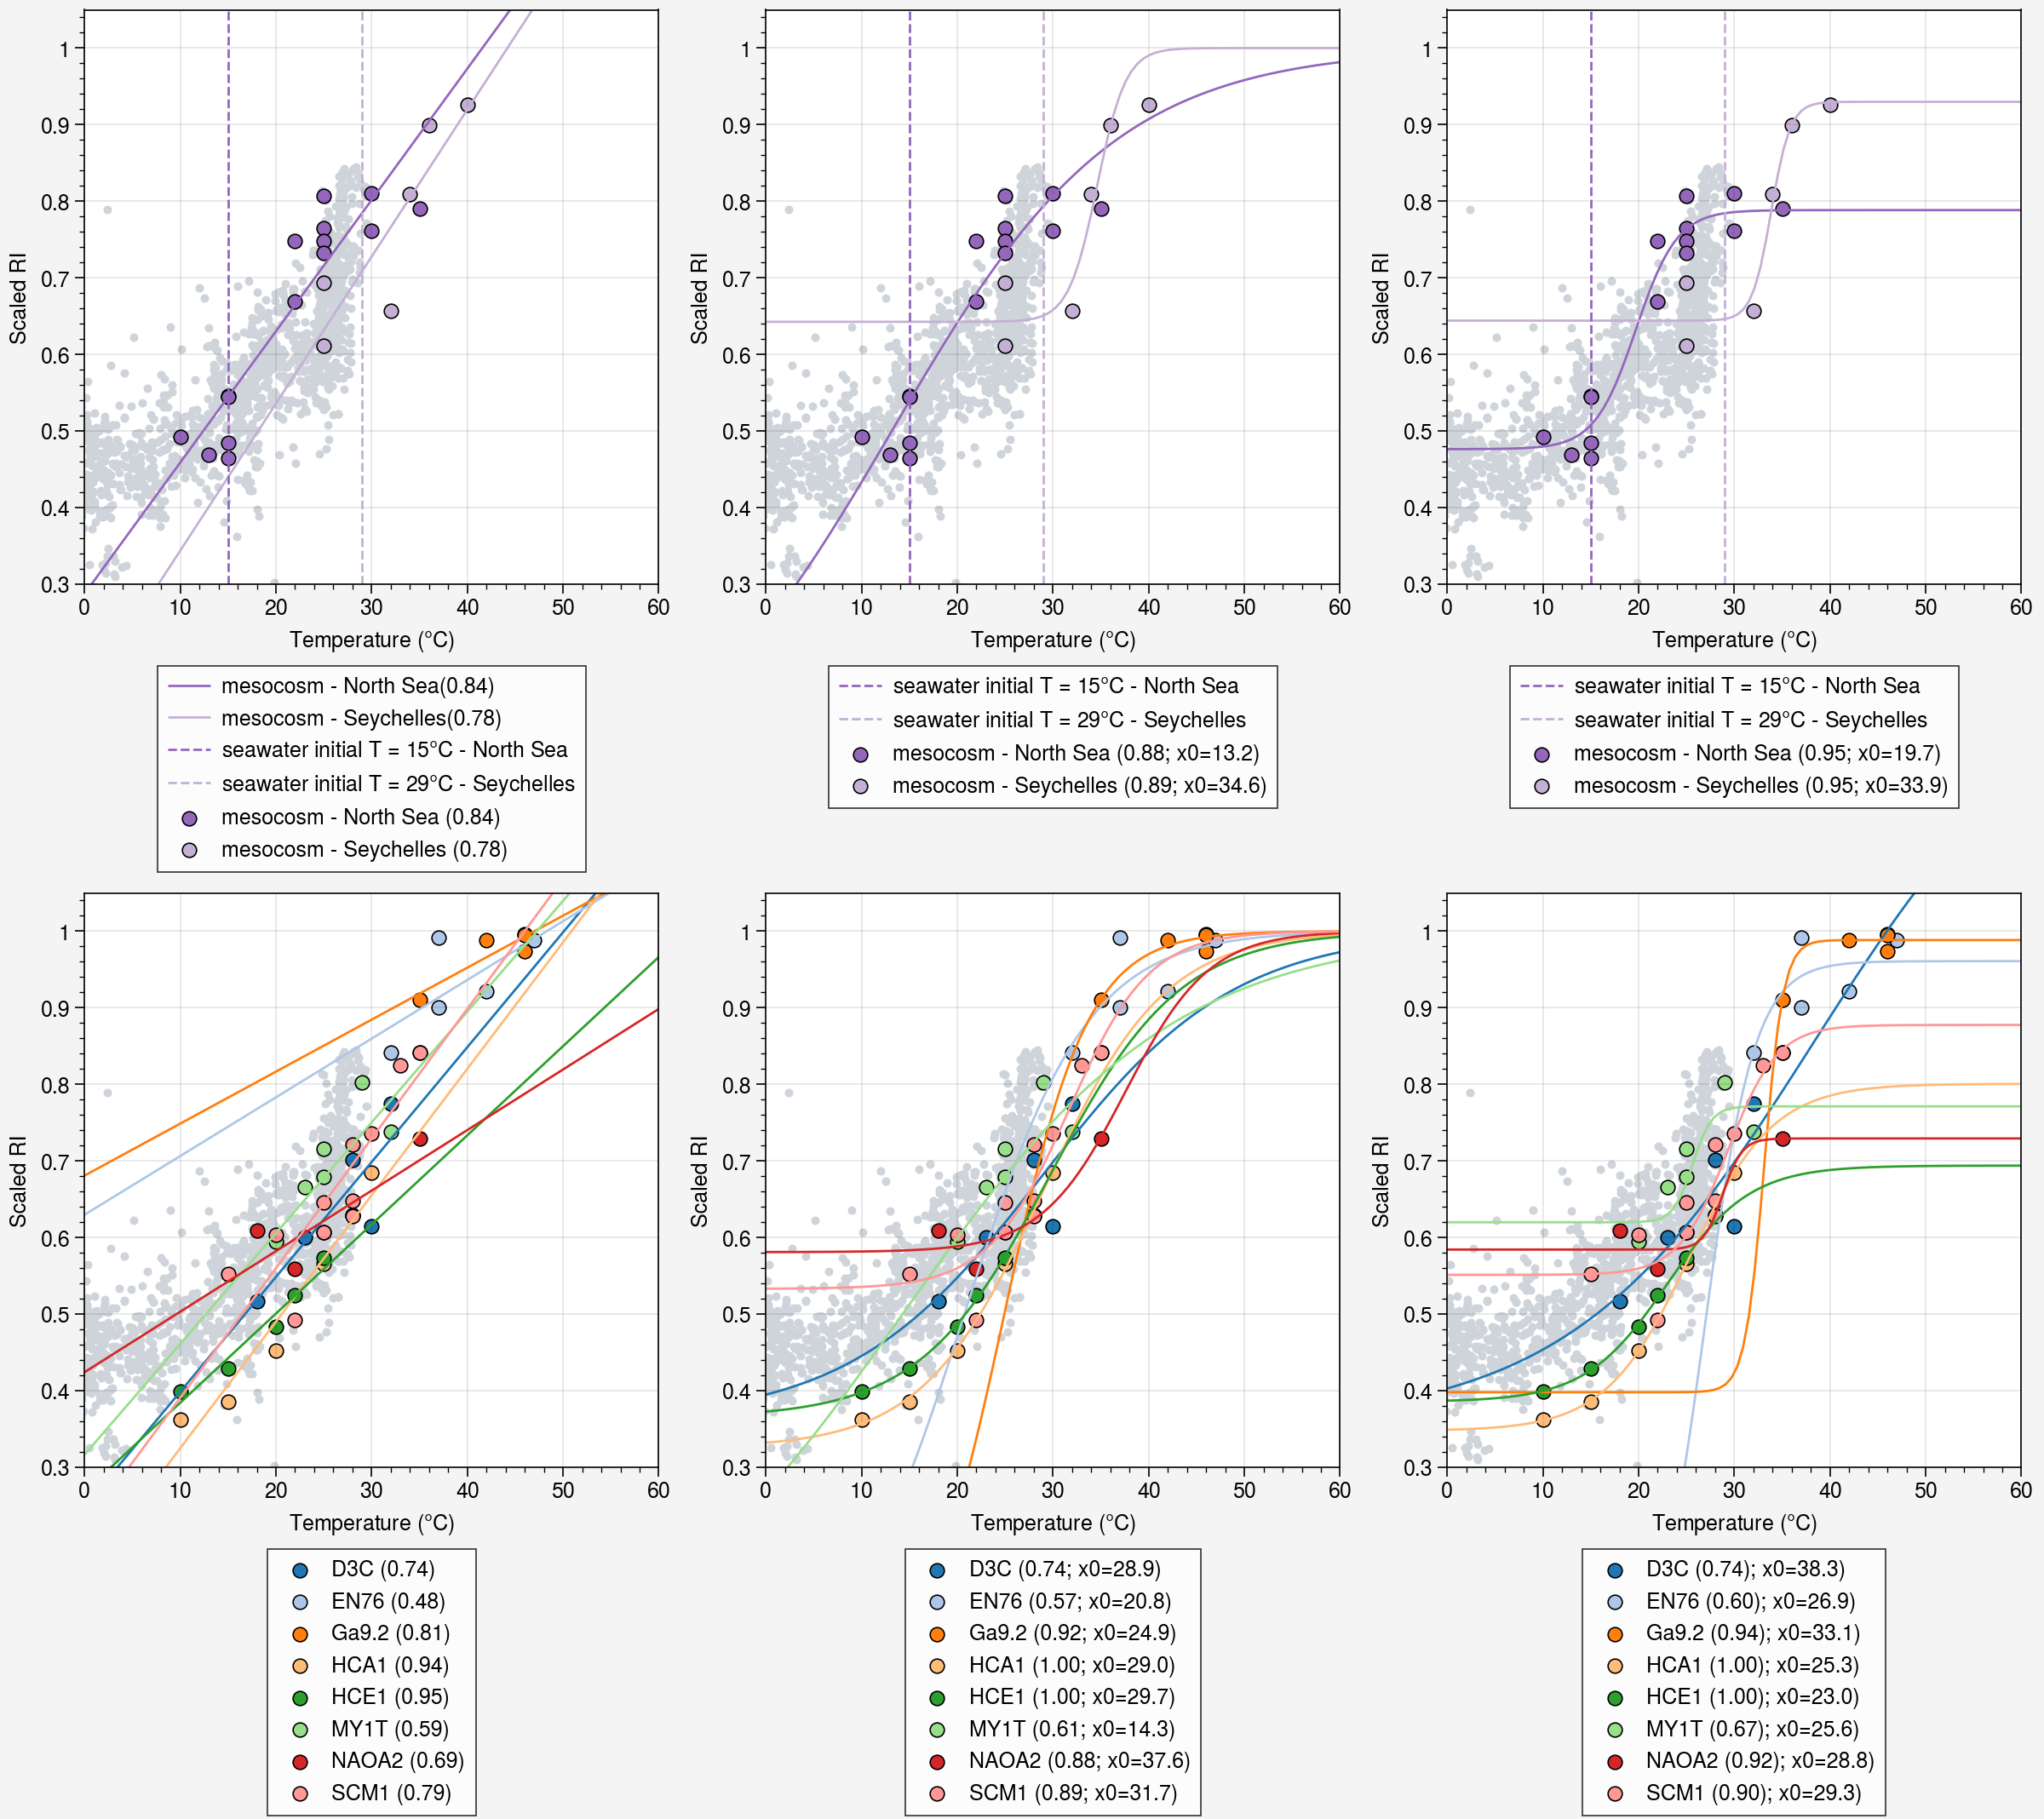

In [19]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=12,ncols=3,nrows=2,share=0)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
data_len_threshold = 5
strains_list = list((plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold).index[plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold])

new_cycler = plot.Cycle('tab20',len(strains_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
strains_colordict = dict(zip(strains_list,list_new_cycler))
grouped = plot_data.groupby('Strains_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= data_len_threshold:
        if 'mesocosm' in name:
                ## linear regression
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                r2 = ols.score(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1,
                                label=name+f'({r2:.2f})')
                axs[0,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')

                ## curve fit logistic fixed
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)
                
                ## score for logistic fixed 
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0_fixed = popt_fixed[0]
                axs[0,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                axs[0,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                
                ## curve fit logistic 
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0, 
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)

                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0 = popt[0]
                axs[0,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0:.1f})', m='o')
                axs[0,2].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)


        else:
            
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[1,0].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score 
                r2 = ols.score(reg_X, reg_y)

                axs[1,0].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')
                

                ### logistic_fixed_upper regression with curve_fit
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)

                fitted_x0_fixed = popt_fixed[0]
                axs[1,1].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                
                ## curve fit logistic
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0,
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)
                fitted_x0 = popt[0]
                axs[1,2].plot(xx_sample, y_sample, c=strains_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                    c=strains_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}); x0={fitted_x0:.1f})', m='o')
                

reg_mesocosm = culture_meso_df[culture_meso_df['experiment_setup']=='mesocosm'].reset_index(drop=True)
X = reg_mesocosm['Temperature'].values.reshape(-1, 1)
y = reg_mesocosm['scaledRI']
ols = LinearRegression()
ols.fit(X, y)
y_sample = ols.predict(xx_sample.reshape(-1, 1))
# axs.plot(xx_sample, y_sample, color='k', lw=1.5, label='OLS (all meso)')

### initial water temperature for mesocosm
axs[0,:].axvline(15, color=strains_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
axs[0,:].axvline(29, color=strains_colordict.get(name,'mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')

for ax in axs[:,:]:
    ax.set_xlabel('Temperature ($\degree$C)')
    ax.set_ylabel('Scaled RI')
    ax.set_xlim(0, 60)
    ax.set_ylim(-0.5, 1.05)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, loc='b', fontsize=8,ncols=1,)

# h0, l0 = axs[0].get_legend_handles_labels()
# axs[0,-1].legend(h0, loc='b', fontsize=8,ncols=1,)

# h1, l1 = axs[1].get_legend_handles_labels()
# axs[1].legend(h1, loc='b', fontsize=8,ncols=1,)

# h2, l2 = axs[2].get_legend_handles_labels()
# axs[2].legend(h2, loc='b', fontsize=8,ncols=1,)

# h3, l3 = axs[3].get_legend_handles_labels()
# axs[3].legend(h3, loc='b', fontsize=8,ncols=1,)

axs.format(ylim=(0.3,1.05),)

#### plot coretop T vs scaledRI
plot_x = coretop_da['t_sf2tc_avg']
plot_y = coretop_da['scaledRI_median']
axs.scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)


/tmp/ipykernel_114955/905057054.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']


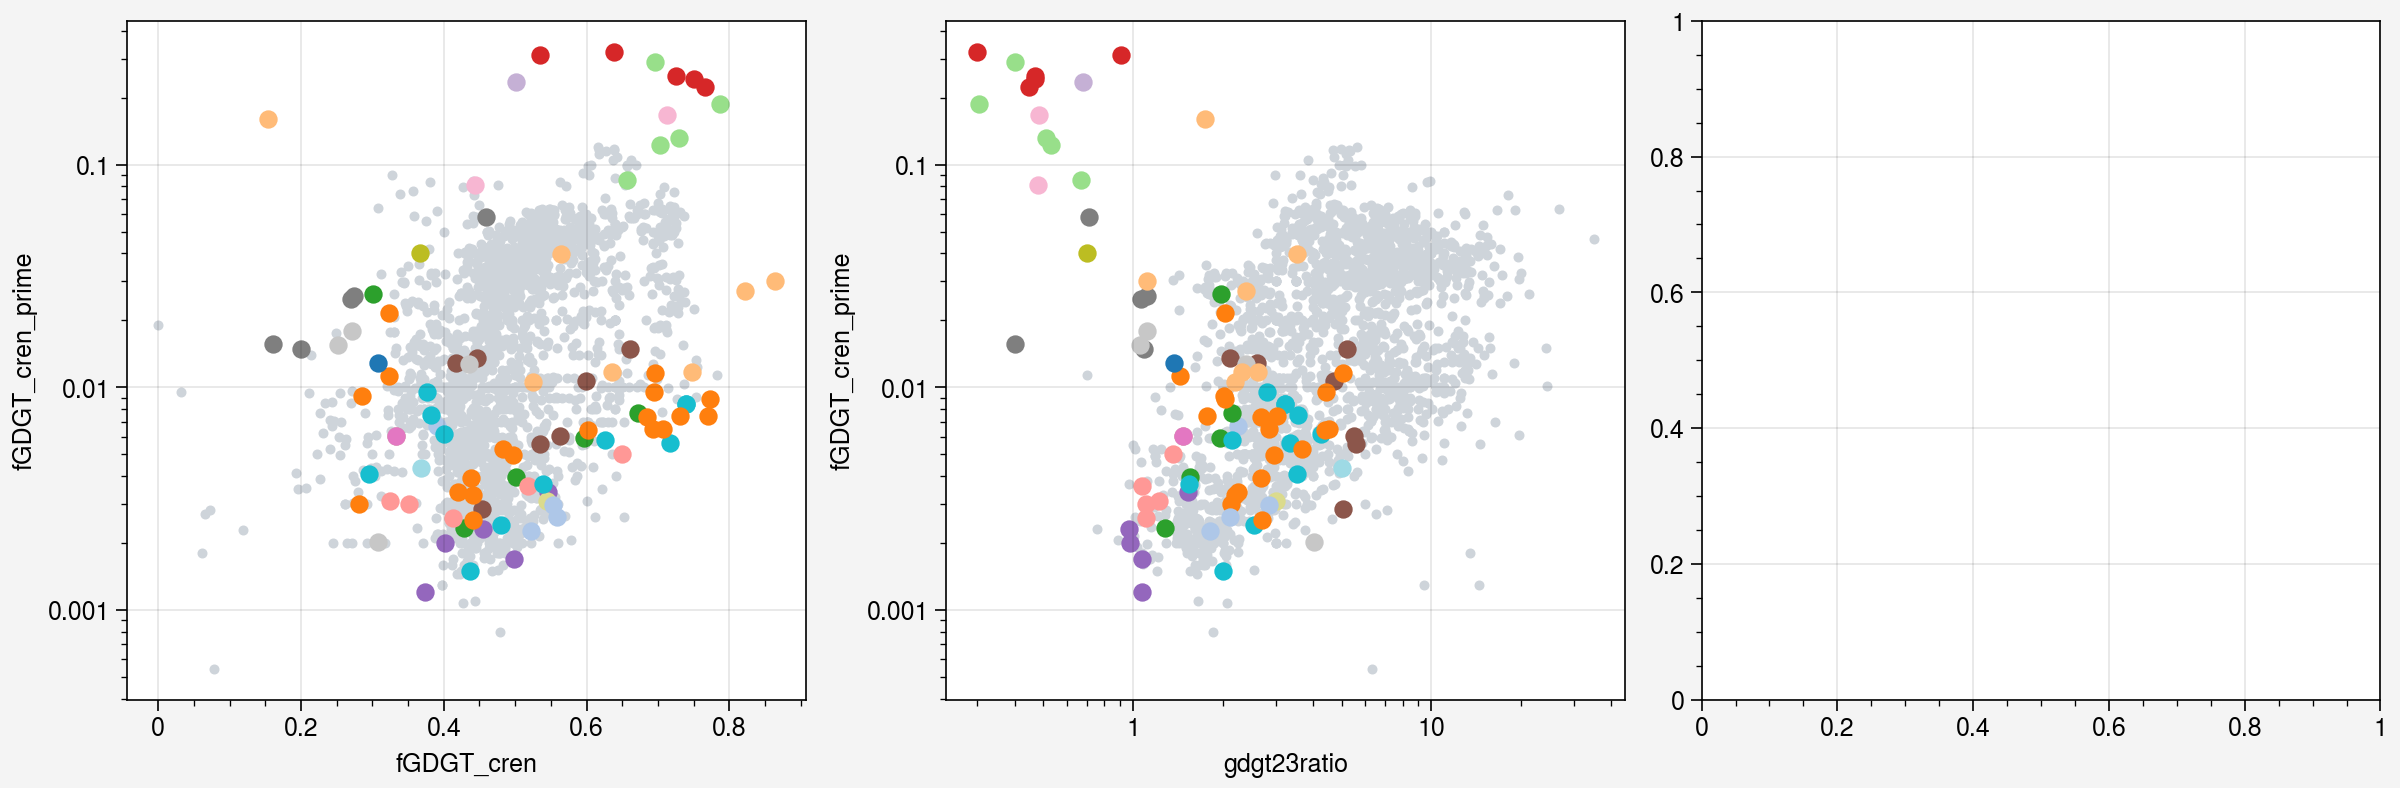

In [20]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=12,ncols=3,nrows=1,share=0)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

data_len_threshold = 0
strains_list = list((plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold).index[plot_data.groupby('Strains_edited')['Strains_edited'].count() >= data_len_threshold])

new_cycler = plot.Cycle('tab20',len(strains_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
strains_colordict = dict(zip(strains_list,list_new_cycler))
grouped = plot_data.groupby('Strains_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= data_len_threshold:
        ### plot cren vs cren'
        plot_x = group['fGDGT_cren']
        plot_y = group['fGDGT_cren_prime']
        axs[0,0].scatter(plot_x, plot_y, c=strains_colordict.get(name,'gray5'), m='o', label=name)
            

        ### plot gdgt23ratio vs cren'
        plot_x = group['gdgt23ratio']
        plot_y = group['fGDGT_cren_prime']
        axs[0,1].scatter(plot_x, plot_y, c=strains_colordict.get(name,'gray5'), m='o', label=name)
            



### plot cren vs cren'
plot_x = raw_coretop_df['fGDGT_cren']
plot_y = raw_coretop_df['fGDGT_cren_prime']
axs[0,0].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[0,0].format(
      yscale='log'
#       ylim=(-0.01, 0.15),
)

### plot gdgt23ratio vs cren'
plot_x = raw_coretop_df['gdgt23ratio']
plot_y = raw_coretop_df['fGDGT_cren_prime']
axs[0,1].scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)
axs[0,1].format(
      yscale='log',
      xscale='log'
#       ylim=(-0.01, 0.15),
)

/tmp/ipykernel_114955/466158521.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
/tmp/ipykernel_114955/466158521.py:110: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  axs[0,:].axvline(15, color=genus_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
/tmp/ipykernel_114955/466158521.py:111: ProplotWarning: Calling arbitrary axes methods from SubplotGrid was deprecated in v0.8 and will be removed in a future release. Please index the grid or loop over the grid instead.
  axs[0,:].axvline(29, color=genus_colordict.get('mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')
/tmp/ipykernel_114955/

(<matplotlib.collections.PathCollection at 0x7f31ce309d20>,
 <matplotlib.collections.PathCollection at 0x7f31ce2bac20>)

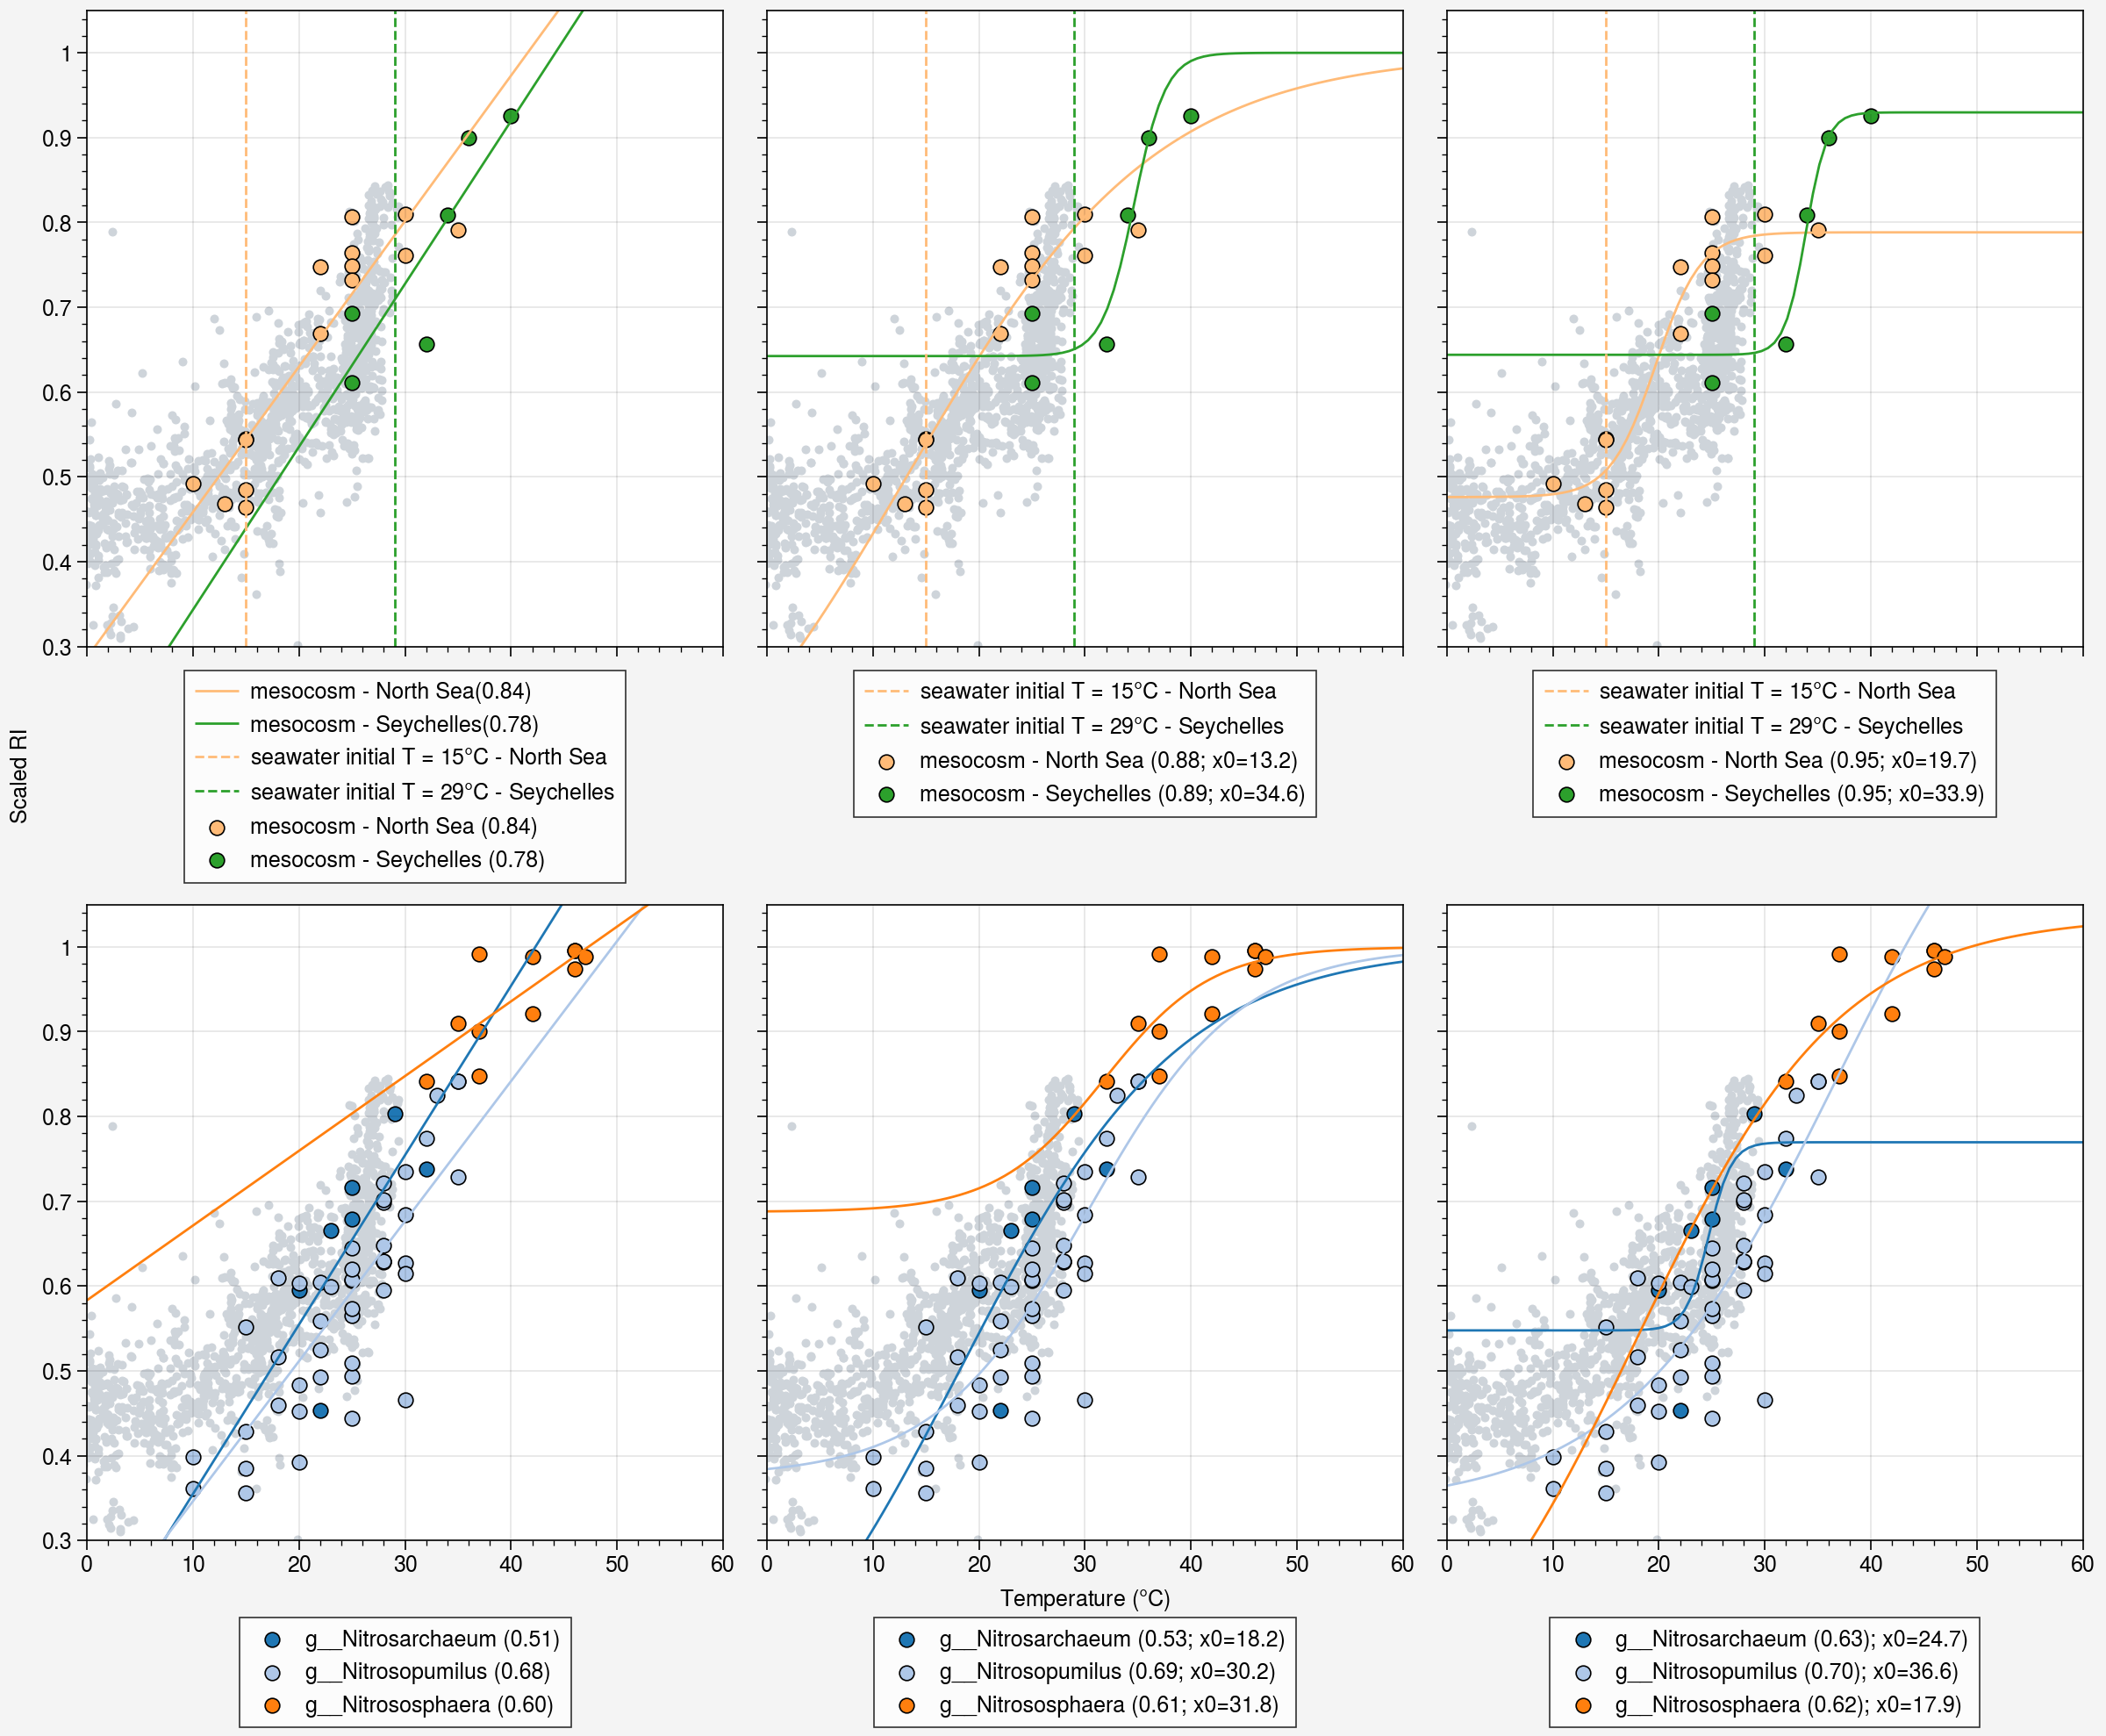

In [21]:
xx_sample = np.linspace(0, 60, 100)
fig, axs = plot.subplots(width=12,ncols=3,nrows=2)
ax = axs[0]
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

genus_list = list((plot_data.groupby('GTDB_genus_edited')['GTDB_genus_edited'].count() >= 0).index[plot_data.groupby('GTDB_genus_edited')['GTDB_genus_edited'].count() >= 5])

new_cycler = plot.Cycle('tab20',len(genus_list))
list_new_cycler = [list(new_cycler)[i].get('color') for i in range(len(list(new_cycler)))]
genus_colordict = dict(zip(genus_list,list_new_cycler))
grouped = plot_data.groupby('GTDB_genus_edited')
for i, (name, group) in enumerate(grouped):
    if len(group) >= 5:
        if 'mesocosm' in name:

                ## linear regression
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                r2 = ols.score(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[0,0].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1,
                                label=name+f'({r2:.2f})')
                axs[0,0].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')

                ## curve fit logistic fixed
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)
                
                ## score for logistic fixed 
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0_fixed = popt_fixed[0]
                axs[0,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                axs[0,1].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                
                ## curve fit logistic 
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0, 
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)

                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                fitted_x0 = popt[0]
                axs[0,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0:.1f})', m='o')
                axs[0,2].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
        else:
            
                reg_X = group['Temperature'].values.reshape(-1, 1)
                reg_y = group['scaledRI']
                ols = LinearRegression()
                ols.fit(reg_X, reg_y)
                y_sample = ols.predict(xx_sample.reshape(-1, 1))
                axs[1,0].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score 
                r2 = ols.score(reg_X, reg_y)

                axs[1,0].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f})', m='o')
                

                ### logistic_fixed_upper regression with curve_fit
                p0_fixed = [25, 0.1, 0.1]
                bounds_fixed = (0, [50, 1, 1])
                popt_fixed, pcov_fixed = scipy.optimize.curve_fit(logistic_fixed_upper, group['Temperature'], group['scaledRI'], p0=p0_fixed, bounds=bounds_fixed)
                y_sample = logistic_fixed_upper(xx_sample, *popt_fixed)

                fitted_x0_fixed = popt_fixed[0]
                axs[1,1].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic_fixed_upper(group['Temperature'], *popt_fixed)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,1].scatter(group['Temperature'], group['scaledRI'],mec='k', 
                        c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}; x0={fitted_x0_fixed:.1f})', m='o')
                
                ## curve fit logistic
                p0 = [25, 0.1, 0.1, 0.1]
                bounds = (0, [50, 1, 1, 1])
                popt, pcov = scipy.optimize.curve_fit(logistic, group['Temperature'], group['scaledRI'], p0=p0,
                                                        bounds=bounds
                                                        )
                y_sample = logistic(xx_sample, *popt)
                fitted_x0 = popt[0]
                axs[1,2].plot(xx_sample, y_sample, c=genus_colordict.get(name,'gray5'), ls='-', lw=1)
                ## score for logistic
                y_residual = group['scaledRI'] - logistic(group['Temperature'], *popt)
                r2 = 1 - (np.var(y_residual) / np.var(group['scaledRI']))
                axs[1,2].scatter(group['Temperature'], group['scaledRI'],mec='k',
                    c=genus_colordict.get(name,'gray5'),label=name+f' ({r2:.2f}); x0={fitted_x0:.1f})', m='o')
            
reg_mesocosm = culture_meso_df[culture_meso_df['experiment_setup']=='mesocosm'].reset_index(drop=True)
X = reg_mesocosm['Temperature'].values.reshape(-1, 1)
y = reg_mesocosm['scaledRI']
ols = LinearRegression()
ols.fit(X, y)
y_sample = ols.predict(xx_sample.reshape(-1, 1))
# axs.plot(xx_sample, y_sample, color='k', lw=1.5, label='OLS (all meso)')

### initial water temperature for mesocosm
axs[0,:].axvline(15, color=genus_colordict.get('mesocosm - North Sea'), ls='--', lw=1, label ='seawater initial T = 15$\degree$C - North Sea')
axs[0,:].axvline(29, color=genus_colordict.get('mesocosm - Seychelles'), ls='--', lw=1, label ='seawater initial T = 29$\degree$C - Seychelles')

for ax in axs:
    ax.set_xlabel('Temperature ($\degree$C)')
    ax.set_ylabel('Scaled RI')
    ax.set_xlim(0, 60)
    ax.set_ylim(-0.5, 1.05)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, loc='b', fontsize=8,ncols=1,)

# h0, l0 = axs[0].get_legend_handles_labels()
# axs[0,-1].legend(h0, loc='b', fontsize=8,ncols=1,)

# h1, l1 = axs[1].get_legend_handles_labels()
# axs[1].legend(h1, loc='b', fontsize=8,ncols=1,)

# h2, l2 = axs[2].get_legend_handles_labels()
# axs[2].legend(h2, loc='b', fontsize=8,ncols=1,)

# h3, l3 = axs[3].get_legend_handles_labels()
# axs[3].legend(h3, loc='b', fontsize=8,ncols=1,)

axs.format(ylim=(0.3,1.05),)

#### plot coretop T vs scaledRI
plot_x = coretop_da['t_sf2tc_avg']
plot_y = coretop_da['scaledRI_median']
axs.scatter(plot_x, plot_y, c='gray4', m='.', zorder=0)

In [22]:
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

# Get strains with at least 5 occurrences
strain_counts = plot_data['Strains_edited'].value_counts()
strains_list = strain_counts[strain_counts >= 5].index.tolist()


plot_data_filtered = plot_data[plot_data['Strains_edited'].isin(strains_list)].reset_index(drop=True)
plot_data_filtered.groupby(['Strains_edited','Source','NCBI_family']).size().sort_values(ascending=False).reset_index(name='counts')

/tmp/ipykernel_114955/690818979.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']


,Strains_edited,Source,NCBI_family,counts
0,mesocosm - North Sea,Wuchter2004,mesocosm,15
1,mesocosm - Seychelles,Schouten2007,mesocosm,6
2,SCM1,Qin et al. (2015) PNAS,f__Nitrosopumilaceae,6
3,HCA1,Qin et al. (2015) PNAS,f__Nitrosopumilaceae,5
4,HCE1,Qin et al. (2015) PNAS,f__Nitrosopumilaceae,5
5,MY1T,Elling et al. Unpublished,f__Nitrosopumilaceae,5
6,EN76,Elling et al. Unpublished,f__Nitrosopumilaceae,4
7,D3C,Elling et al. Unpublished,f__Nitrosopumilaceae,4
8,NAOA2,Elling et al. (2015) GCA,f__Nitrosopumilaceae,4
9,SCM1,Elling et al. (2015) GCA,f__Nitrosopumilaceae,4


/tmp/ipykernel_114955/456440541.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']


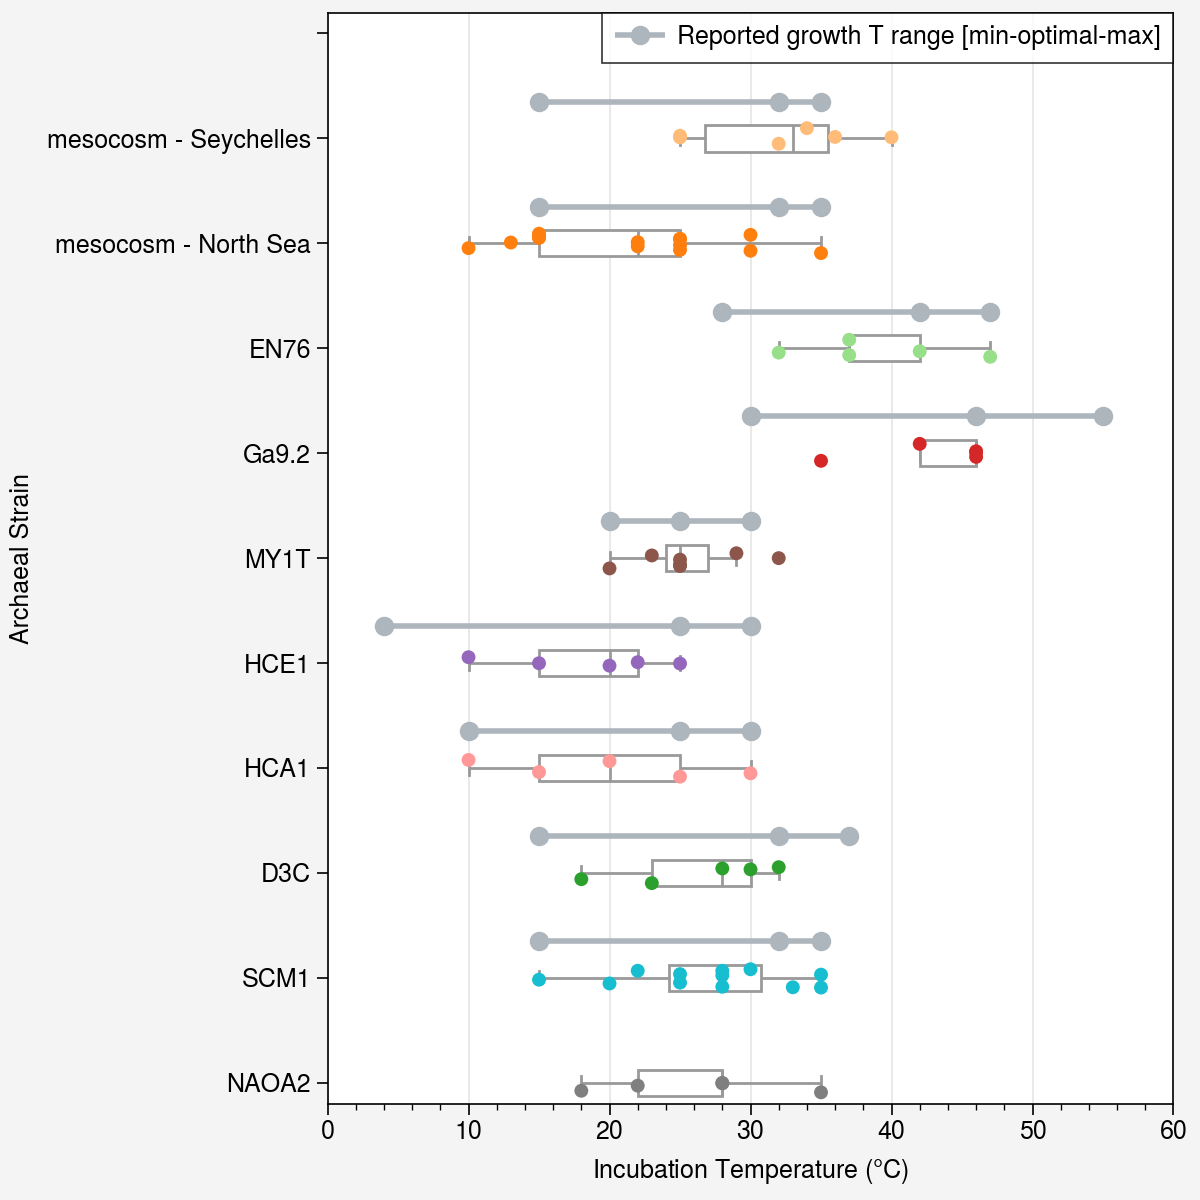

In [23]:
plot_data = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

# Get strains with at least 5 occurrences
strain_counts = plot_data['Strains_edited'].value_counts()
strains_list = strain_counts[strain_counts >= 5].index.tolist()


plot_data_filtered = plot_data[plot_data['Strains_edited'].isin(strains_list)].reset_index(drop=True)

# Define the known optimal temperature ranges for each strain
optimal_temp_ranges = {
    ### information from BacDive bacdive.dsmz.de
    'D3C': (15, 32, 37), ## Elling et al (unpublished) | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'EN76': (28, 42, 47), ## N. viennensis | Elling et al (unpublished) | Stieglmeier et al. 2014 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijs.0.063172-0), Tourna et al. 2011 (PNAS; https://www.pnas.org/doi/10.1073/pnas.1013488108#fig01)
    'Ga9.2': (30, 46, 55), ## N. Gargensis | Pitcher et al. (2010), Elling et al. (2017) | Chow et al. (2018) (https://www.nature.com/articles/s41598-018-32059-0#:~:text=The%20carboxylesterase%20was%20mostly%20active,(%E2%88%BC46%20%C2%B0C).)
    'HCA1': (10, 25, 30), ## Qin et al. (2015) PNAS | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'HCE1': (4, 25, 30), ## Qin et al. (2015) PNAS | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'MY1T': (20, 25,30), ## Jung et al. (2011) GDGT and growth conditions
    # 'NAOA2': (25, 35), ## 
    'SCM1': (15, 32, 35), ## Elling et al. (2015) GCA & Qin et al. (2015) PNAS  | Bayer et al. 2019 (https://www.microbiologyresearch.org/content/journal/ijsem/10.1099/ijsem.0.003360)
    'mesocosm - North Sea': (15, 32, 35), ## Assuming close to SCM1 based on phylogenetic tree of Wuchter et al. (2004) PNAS
    'mesocosm - Seychelles': (15, 32, 35),  ## Assuming close to SCM1 based on phylogenetic tree of Schouten et al. (2007) Organic Geochemistry
}
# Get unique strains in the correct plotting order
strain_order = plot_data_filtered['Strains_edited'].unique()

fig, axs = plot.subplots(figsize=(6,6))
ax = axs[0]

sns.stripplot(data=plot_data_filtered, x='Temperature', y='Strains_edited', 
              hue='Strains_edited', palette=strains_colordict, legend=False,
              ax=ax)
sns.boxplot(data=plot_data_filtered, x='Temperature', y='Strains_edited', 
            color='white', ax=ax, linewidth=1, fliersize=0, legend=False,
            width=0.25)

# Add horizontal bars for optimal temperature ranges
for strain, (temp_min, temp_opt, temp_max) in optimal_temp_ranges.items():
    if strain in strain_order:  # Ensure the strain exists in the filtered data
        y_pos = np.where(strain_order == strain)[0][0]  # Find index in strain_order
        ax.plot([temp_min, temp_opt, temp_max], [y_pos+0.35, y_pos+0.35, y_pos+0.35], m='o', ls='-', c='gray5', lw=2, label='Optimal T range')


### add 'source' from the dataframe to each line


ax.format(
    yticks=np.arange(0, len(plot_data_filtered['Strains_edited'].unique()) + 0.5, 1),
    yticklabels=list(plot_data_filtered['Strains_edited'].unique()),
    ytickminor=False,
    xlabel='Incubation Temperature ($\degree$C)',
    ylabel='Archaeal Strain',
    xlim=(0, 60),
    ylim=(-0.2, len(plot_data_filtered['Strains_edited'].unique()) + 0.2),
)

h, l = ax.get_legend_handles_labels()
ax.legend(h[0], 'Reported growth T range [min-optimal-max]', loc='ur', fontsize=8,ncols=1, title_fontsize=8)



In [24]:
SCM1_df = culture_meso_df[culture_meso_df['Strains']=='SCM1'].reset_index(drop=True)
SCM1_df

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR011,Elling2015_Culture_SCM1_22,Elling et al. (2015) GCA,22,0.609589,1.970408,0.492602,3.534483,7.0,p__Thermoproteota,...,0.059184,0.295918,0.004082,culture,0.596154,0.464945,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
1,TEXAS_PSM_culture_RR012,Elling2015_Culture_SCM1_25,Elling et al. (2015) GCA,25,0.708333,2.428571,0.607143,4.263158,7.0,p__Thermoproteota,...,0.058582,0.399794,0.006166,culture,0.518879,0.280961,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
2,TEXAS_PSM_culture_RR013,Elling2015_Culture_SCM1_28,Elling et al. (2015) GCA,28,0.787234,2.511603,0.627901,2.800000,7.0,p__Thermoproteota,...,0.100211,0.376582,0.009494,culture,0.557437,0.253138,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
3,TEXAS_PSM_culture_RR014,Elling2015_Culture_SCM1_35,Elling et al. (2015) GCA,35,0.767980,3.367337,0.841834,3.226361,7.0,p__Thermoproteota,...,0.034903,0.739174,0.008401,culture,0.206560,0.072531,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR016,Elling2017_culture_marineAOA_totalGDGTs_Nitros...,Elling et al. (2017) Environmnental Microbiology,28,0.825626,2.593610,0.648403,3.556175,7.0,p__Thermoproteota,...,0.093497,0.381596,0.007547,culture,0.570811,0.196473,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
5,TEXAS_PSM_culture_RR020,Qin2015_001_Nitrosopumilus maritimus SCM1_Cult...,Qin et al. (2015) PNAS,15,0.456621,2.207300,0.551825,2.002336,7.0,p__Thermoproteota,...,0.042800,0.436700,0.001500,culture,0.392570,0.389487,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
6,TEXAS_PSM_culture_RR021,Qin2015_002_Nitrosopumilus maritimus SCM1_Cult...,Qin et al. (2015) PNAS,20,0.524444,2.412900,0.603225,2.544601,7.0,p__Thermoproteota,...,0.042600,0.479900,0.002400,culture,0.375583,0.321696,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
7,TEXAS_PSM_culture_RR022,Qin2015_003_Nitrosopumilus maritimus SCM1_Cult...,Qin et al. (2015) PNAS,25,0.508786,2.580600,0.645150,1.537815,7.0,p__Thermoproteota,...,0.047600,0.539100,0.003700,culture,0.307476,0.286244,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
8,TEXAS_PSM_culture_RR023,Qin2015_004_Nitrosopumilus maritimus SCM1_Cult...,Qin et al. (2015) PNAS,30,0.597912,2.941200,0.735300,2.144165,7.0,p__Thermoproteota,...,0.043700,0.625800,0.005800,culture,0.270080,0.177120,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus
9,TEXAS_PSM_culture_RR024,Qin2015_005_Nitrosopumilus maritimus SCM1_Cult...,Qin et al. (2015) PNAS,33,0.723797,3.299200,0.824800,3.362360,7.0,p__Thermoproteota,...,0.035600,0.717300,0.005600,culture,0.230630,0.077665,0,culture-temperature_Marine mesophile,SCM1,g__Nitrosopumilus


# 4. Build culRI-Bayesian model

## 4.1 Layer 1: Build the base model of RI vs temperature based on culture+mesocosm data

In [25]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)

x = culture_data_full['Temperature'].astype(float).tolist() 
y = culture_data_full['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_data_full),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"), compile=True)

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_cultureOnlyFull = fit.stan_variable("x0")
k_post_cultureOnlyFull = fit.stan_variable("k")
b_post_cultureOnlyFull = fit.stan_variable("b")
sigma_post_cultureOnlyFull = fit.stan_variable("sigma")


/tmp/ipykernel_114955/1078954627.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
15:21:56 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.
15:21:56 - cmdstanpy - INFO - Chain [1] start processing
15:21:56 - cmdstanpy - INFO - Chain [2] start processing
15:21:56 - cmdstanpy - INFO - Chain [3] start processing
15:21:56 - cmdstanpy - INFO - Chain [4] start processing
15:21:56 - cmdstanpy - INFO - Chain [1] done processing
15:21:56 - cmdstanpy - INFO - Chain [3] done processing
15:21:56 - cmdstanpy - INFO - Chain [2] done processing
15:21:56 - cmdstanpy - INFO - Chain [4] done processing
15:21:56 - cmdstanpy - WARNING - Non-fa

Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmp1k41w4e4/wrtpuqav.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Cha

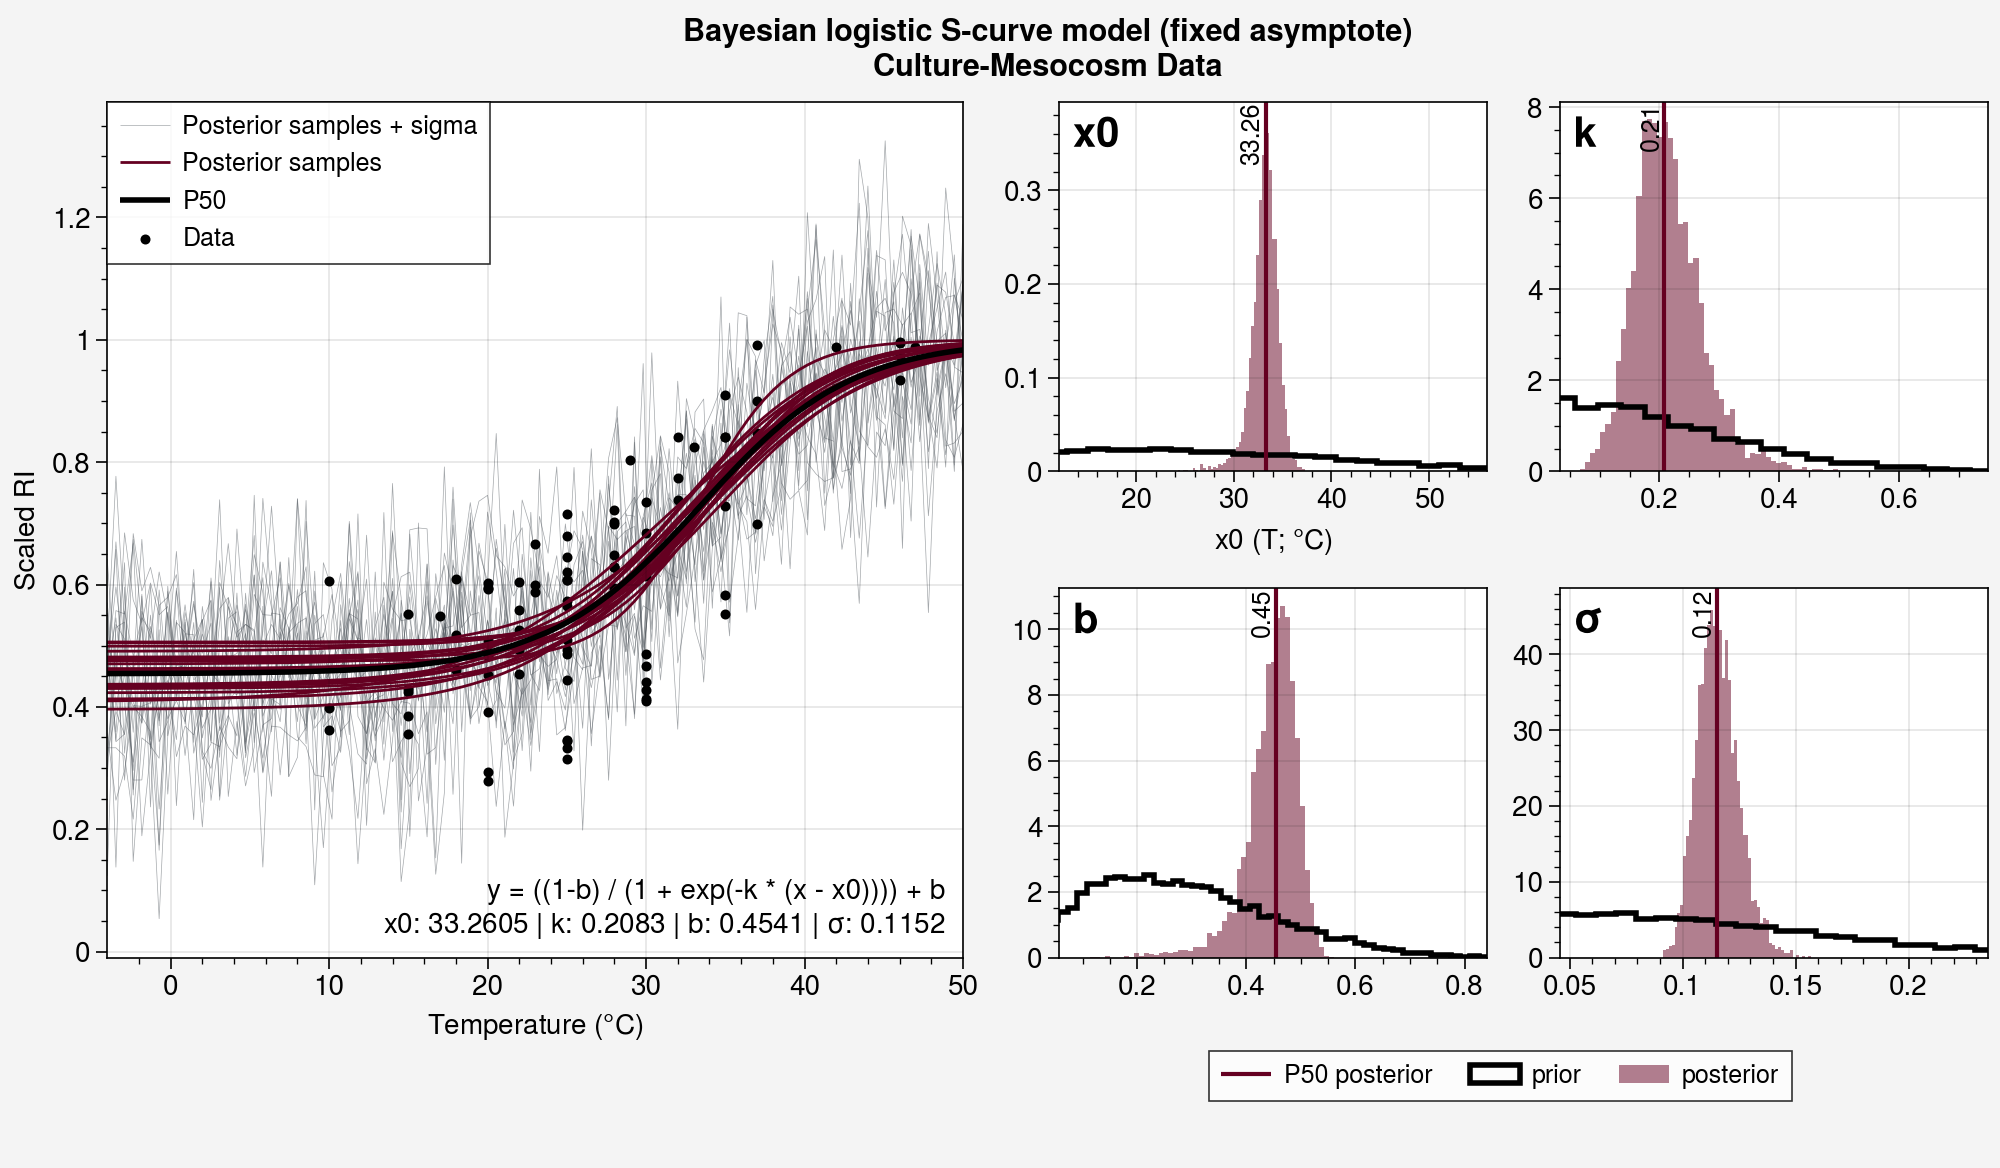

In [26]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_culture_full_samples = []
RI_pred_culture_full_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_cultureOnlyFull))
        x0 = x0_post_cultureOnlyFull[i]
        k = k_post_cultureOnlyFull[i]
        b = b_post_cultureOnlyFull[i]
        sigma = sigma_post_cultureOnlyFull[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_full_samples.append(y_pred)
        RI_pred_culture_full_noisy_samples.append(y_pred_noisy)
RI_pred_culture_full_samples = np.array(RI_pred_culture_full_samples)
RI_p50 = np.percentile(RI_pred_culture_full_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_culture_full_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_culture_full_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_full_samples))
        ax.plot(x_sample, RI_pred_culture_full_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_full_samples))
        ax.plot(x_sample, RI_pred_culture_full_samples[rand_idx], color="maroon", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="maroon", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_post_cultureOnlyFull,50)
ax.axvline(p50_x0, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_post_cultureOnlyFull,50)
ax.axvline(p50_k, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_post_cultureOnlyFull,50)
ax.axvline(p50_b, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post_cultureOnlyFull, bins=50, color='maroon', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_post_cultureOnlyFull,50)
ax.axvline(p50_sigma, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50 = np.percentile(x0_post_cultureOnlyFull,50)
k_p50 = np.percentile(k_post_cultureOnlyFull,50)
b_p50 = np.percentile(b_post_cultureOnlyFull,50)
sigma_p50 = np.percentile(sigma_post_cultureOnlyFull,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50:.4f} | k: {k_p50:.4f} | b: {b_p50:.4f} | $\sigma$: {sigma_p50:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

### limit xlim to be min-max of posterior of each params
params = [x0_post_cultureOnlyFull,k_post_cultureOnlyFull,b_post_cultureOnlyFull,sigma_post_cultureOnlyFull]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

In [27]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_mesocosm_data = culture_meso_df[culture_meso_df['Temperature']<50]

x = culture_mesocosm_data['Temperature'].astype(float).tolist() 
y = culture_mesocosm_data['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_mesocosm_data),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"), compile=True)

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post = fit.stan_variable("x0")
k_post = fit.stan_variable("k")
b_post = fit.stan_variable("b")
sigma_post = fit.stan_variable("sigma")


15:21:56 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.
15:21:56 - cmdstanpy - INFO - Chain [1] start processing
15:21:56 - cmdstanpy - INFO - Chain [2] start processing
15:21:56 - cmdstanpy - INFO - Chain [3] start processing
15:21:56 - cmdstanpy - INFO - Chain [4] start processing
15:21:57 - cmdstanpy - INFO - Chain [4] done processing
15:21:57 - cmdstanpy - INFO - Chain [3] done processing
15:21:57 - cmdstanpy - INFO - Chain [2] done processing
15:21:57 - cmdstanpy - INFO - Chain [1] done processing
15:21:57 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'logistic_fixed_asymptote.stan', line 22, column 2 to column 35)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'logistic_fixed

Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmp1k41w4e4/243cbu9n.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Cha

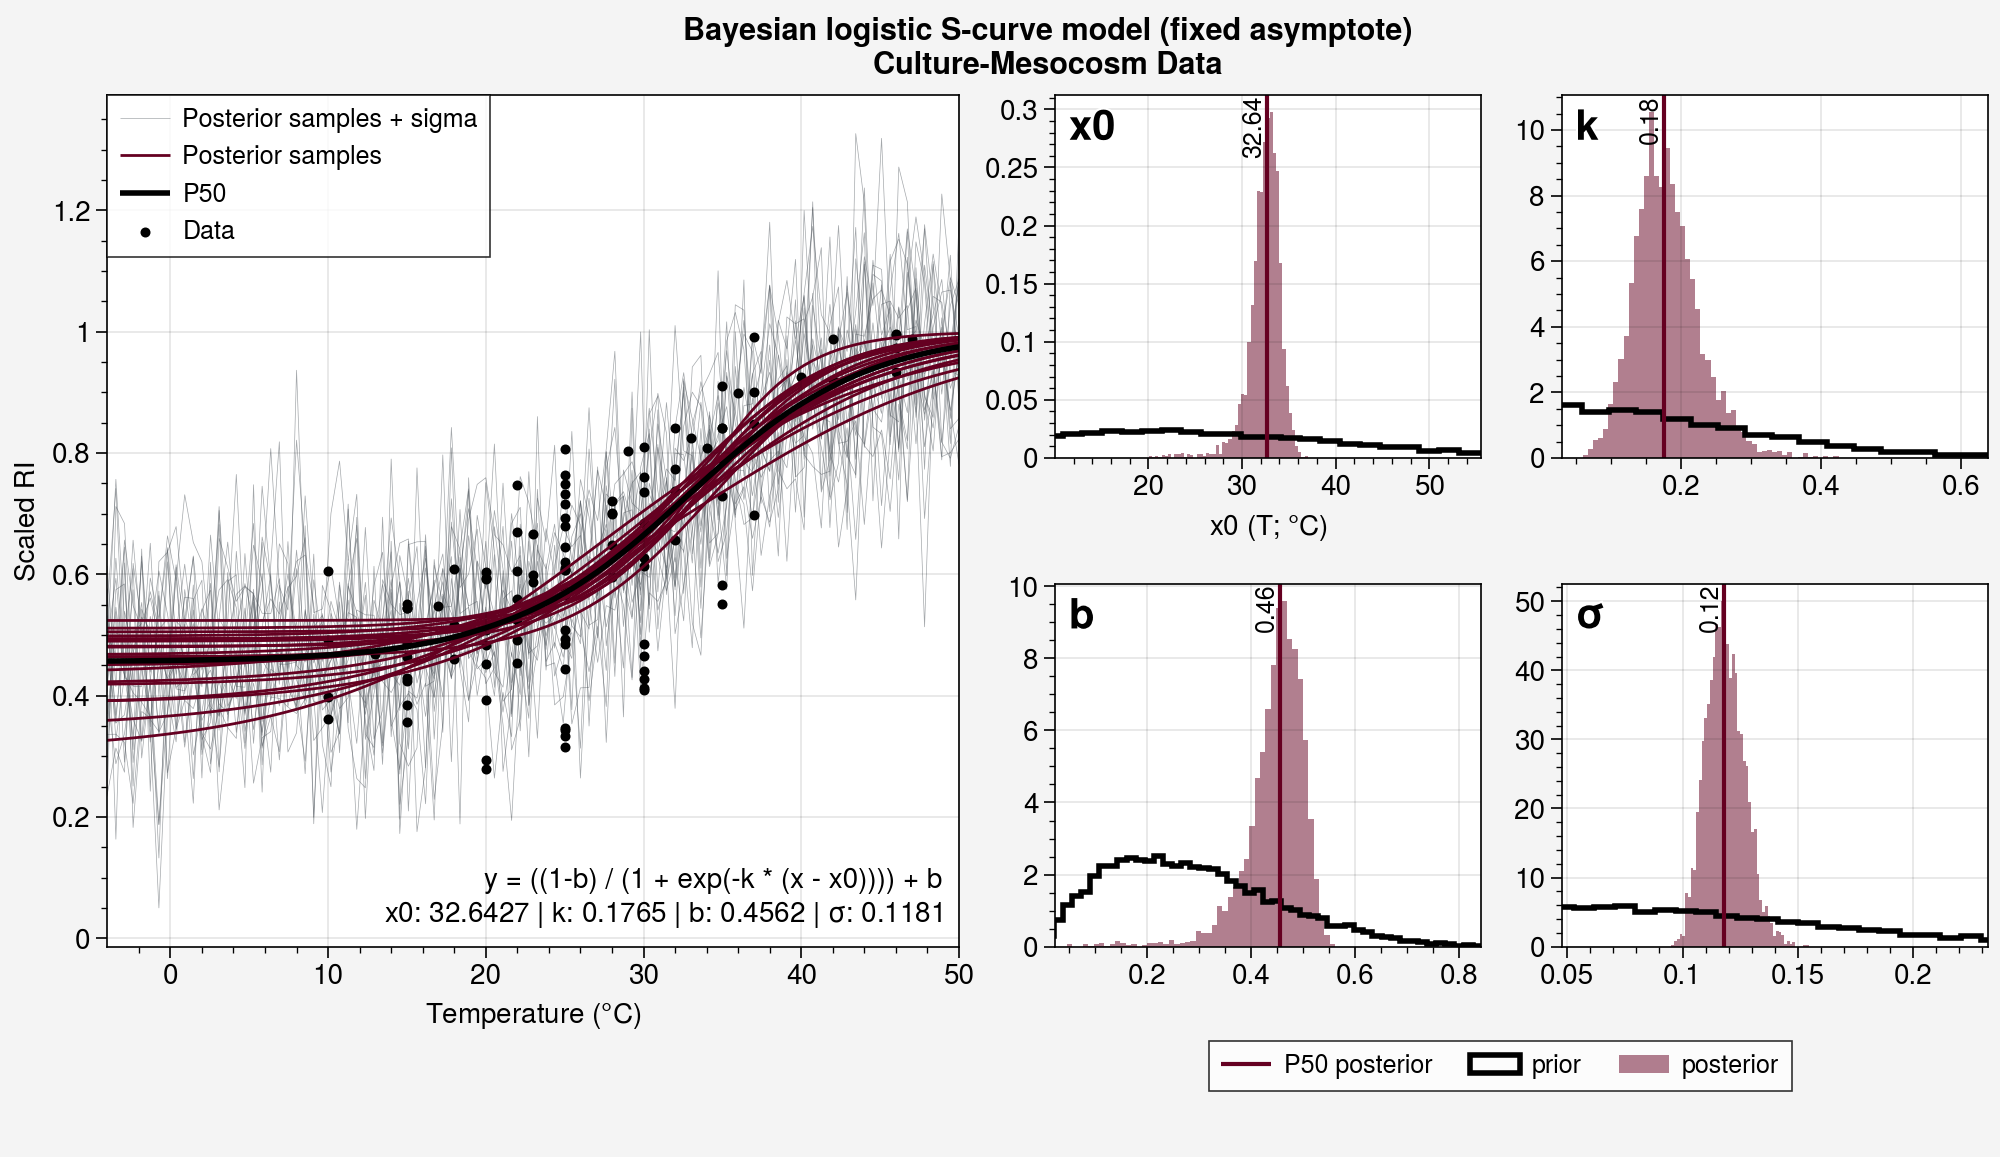

In [28]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_culture_meso_samples = []
RI_pred_culture_meso_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post))
        x0 = x0_post[i]
        k = k_post[i]
        b = b_post[i]
        sigma = sigma_post[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_meso_samples.append(y_pred)
        RI_pred_culture_meso_noisy_samples.append(y_pred_noisy)
RI_pred_culture_meso_samples = np.array(RI_pred_culture_meso_samples)
RI_p50 = np.percentile(RI_pred_culture_meso_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_culture_meso_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_culture_meso_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_samples))
        ax.plot(x_sample, RI_pred_culture_meso_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_samples))
        ax.plot(x_sample, RI_pred_culture_meso_samples[rand_idx], color="maroon", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="maroon", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_post, bins=50, color='maroon', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_post,50)
ax.axvline(p50_x0, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_post, bins=50, color='maroon', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_post,50)
ax.axvline(p50_k, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_post, bins=50, color='maroon', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_post,50)
ax.axvline(p50_b, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post, bins=50, color='maroon', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_post,50)
ax.axvline(p50_sigma, color='maroon', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50 = np.percentile(x0_post,50)
k_p50 = np.percentile(k_post,50)
b_p50 = np.percentile(b_post,50)
sigma_p50 = np.percentile(sigma_post,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50:.4f} | k: {k_p50:.4f} | b: {b_p50:.4f} | $\sigma$: {sigma_p50:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

### limit xlim to be min-max of posterior of each params
params = [x0_post,k_post,b_post,sigma_post]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

In [29]:
culture_mesocosm_data['GTDB_family'].unique()

array(['f__Nitrosopumilaceae', 'f__Nitrososphaeraceae',
       '\xa0f__Nitrosopumilaceae', 'mesocosm'], dtype=object)

In [30]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['GTDB_family'].isin(['f__Nitrosopumilaceae','mesocosm'])][
        culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']

x = culture_mesocosm_data_nitros['Temperature'].astype(float).tolist() 
y = culture_mesocosm_data_nitros['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_mesocosm_data_nitros),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"), compile=True)

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_nitros = fit.stan_variable("x0")
k_post_nitros = fit.stan_variable("k")
b_post_nitros = fit.stan_variable("b")
sigma_post_nitros = fit.stan_variable("sigma")


/tmp/ipykernel_114955/2116504085.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
/tmp/ipykernel_114955/2116504085.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
15:21:57 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.
15:21:57 - cmdstanpy - INFO - Chain [1] start processing
15:21:58 - cmdstanpy - INFO - Chain [2] start processing
15:21:58 - cmdstanpy - INFO - Chain [3] start processing
15:21:58 - cmdstanpy - INFO - Chain [4] start processing
15:21:58 - cmdstanpy - INFO - Chain [1] done processing
15:21:58 - cmdstanpy - INFO - Chain [2] done processing
15

Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmp1k41w4e4/pmoz7hx9.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Cha

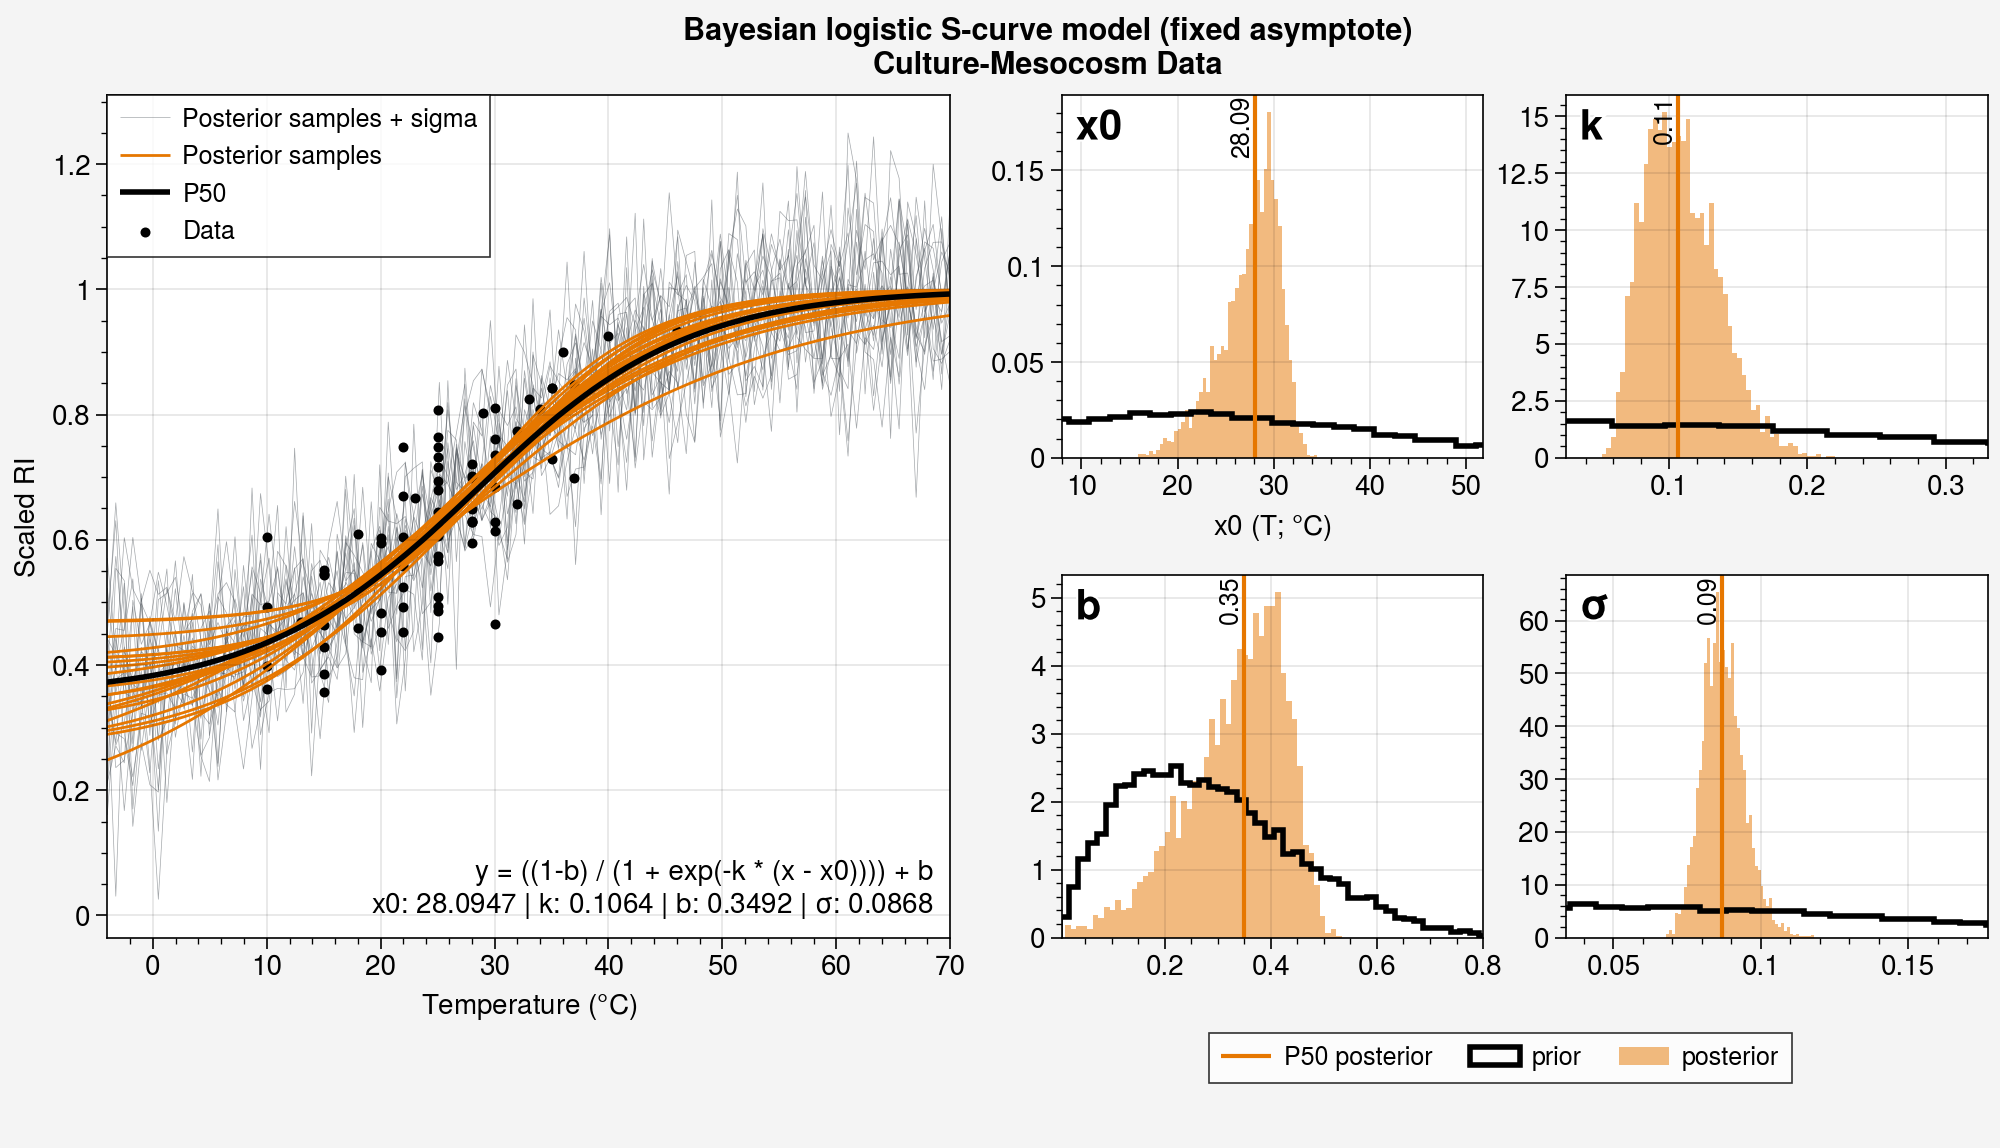

In [31]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,70, 100)
RI_pred_culture_meso_nitros_samples = []
RI_pred_culture_meso_nitros_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_nitros))
        x0 = x0_post_nitros[i]
        k = k_post_nitros[i]
        b = b_post_nitros[i]
        sigma = sigma_post_nitros[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_meso_nitros_samples.append(y_pred)
        RI_pred_culture_meso_nitros_noisy_samples.append(y_pred_noisy)
RI_pred_culture_meso_nitros_samples = np.array(RI_pred_culture_meso_nitros_samples)
RI_p50 = np.percentile(RI_pred_culture_meso_nitros_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_culture_meso_nitros_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_culture_meso_nitros_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_nitros_samples))
        ax.plot(x_sample, RI_pred_culture_meso_nitros_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_nitros_samples))
        ax.plot(x_sample, RI_pred_culture_meso_nitros_samples[rand_idx], color="yellow9", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)
ax.scatter(x, y, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="yellow9", alpha=0.2, label="P5-P95")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_post_nitros, bins=50, color='yellow9', alpha=0.5, label="x0", density=True)
p50_x0_nitros = np.percentile(x0_post_nitros,50)
ax.axvline(p50_x0_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0_nitros, hist_height,f"{p50_x0_nitros:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_post_nitros, bins=50, color='yellow9', alpha=0.5, label="k", density=True)
p50_k_nitros = np.percentile(k_post_nitros,50)
ax.axvline(p50_k_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k_nitros, hist_height,f"{p50_k_nitros:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_post_nitros, bins=50, color='yellow9', alpha=0.5, label="b", density=True)
p50_b_nitros = np.percentile(b_post_nitros,50)
ax.axvline(p50_b_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b_nitros, hist_height,f"{p50_b_nitros:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_post_nitros, bins=50, color='yellow9', alpha=0.5, label="sigma", density=True)
p50_sigma_nitros = np.percentile(sigma_post_nitros,50)
ax.axvline(p50_sigma_nitros, color='yellow9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma_nitros, hist_height,f"{p50_sigma_nitros:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50_nitros = np.percentile(x0_post_nitros,50)
k_p50_nitros = np.percentile(k_post_nitros,50)
b_p50_nitros = np.percentile(b_post_nitros,50)
sigma_p50_nitros = np.percentile(sigma_post_nitros,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50_nitros:.4f} | k: {k_p50_nitros:.4f} | b: {b_p50_nitros:.4f} | $\sigma$: {sigma_p50_nitros:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

### limit xlim to be min-max of posterior of each params
params = [x0_post_nitros,k_post_nitros,b_post_nitros,sigma_post_nitros]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

In [32]:
# build the base model from culture data using Bayesian stats on hyperparameters of logistic regression using pystan

import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel



culture_mesocosm_data_filtered = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
culture_mesocosm_excluded = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']=='Verma et al. (2024) Biogeosciences']
x = culture_mesocosm_data_filtered['Temperature'].astype(float).tolist() 
y = culture_mesocosm_data_filtered['scaledRI'].astype(float).tolist() 
# Save data for Stan
data = {
    "N": len(culture_mesocosm_data_filtered),
    "x": x,
    "y": y
}

# Compile the model (ensure the .stan file is in the same directory)
model = CmdStanModel(stan_file=os.path.join(stan_models_path, "logistic_fixed_asymptote.stan"), compile=True)

# Fit the model
fit = model.sample(data=data, 
                   chains=4, 
                   iter_warmup=500, 
                   iter_sampling=1000, 
                   seed=42,
                   parallel_chains=4,
                   show_console=True)

# Extract results
summary = fit.summary()
print(summary)

# Extract posterior samples
x0_post_filtered = fit.stan_variable("x0")
k_post_filtered = fit.stan_variable("k")
b_post_filtered = fit.stan_variable("b")
sigma_post_filtered = fit.stan_variable("sigma")


/tmp/ipykernel_114955/3442655137.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_filtered = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
/tmp/ipykernel_114955/3442655137.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_excluded = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']=='Verma et al. (2024) Biogeosciences']
15:21:58 - cmdstanpy - WARNING - CmdStanModel(compile=...) is deprecated and will be removed in the next major version. The constructor will always ensure a model has a compiled executable.
If you wish to force recompilation, use force_compile=True instead.
15:21:58 - cmdstanpy - INFO - Chain [1] start processing
15:21:58 - cmdstanpy - INFO - Chain [2] start processing
15:21:58 - cmdstanpy - INFO - Chain [3] start processing
15:21:58 - cmdstanpy - INFO - Chain [4] sta

Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [2] method = sample (Default)
Chain [2] sample
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmp1k41w4e4/aqe3gtvu.json
Chain [1] init = 2 (Default)
Chai

/tmp/ipykernel_114955/1513286490.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_nonNitros = culture_meso_df[culture_meso_df['Temperature']<50][
/tmp/ipykernel_114955/1513286490.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_nonNitros = culture_meso_df[culture_meso_df['Temperature']<50][
/tmp/ipykernel_114955/1513286490.py:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
/tmp/ipykernel_114955/1513286490.py:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
/tmp/ipykernel_114955/1513286490.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  culture_mesocosm_excluded = culture_meso_df[culture_meso_df['Temperature

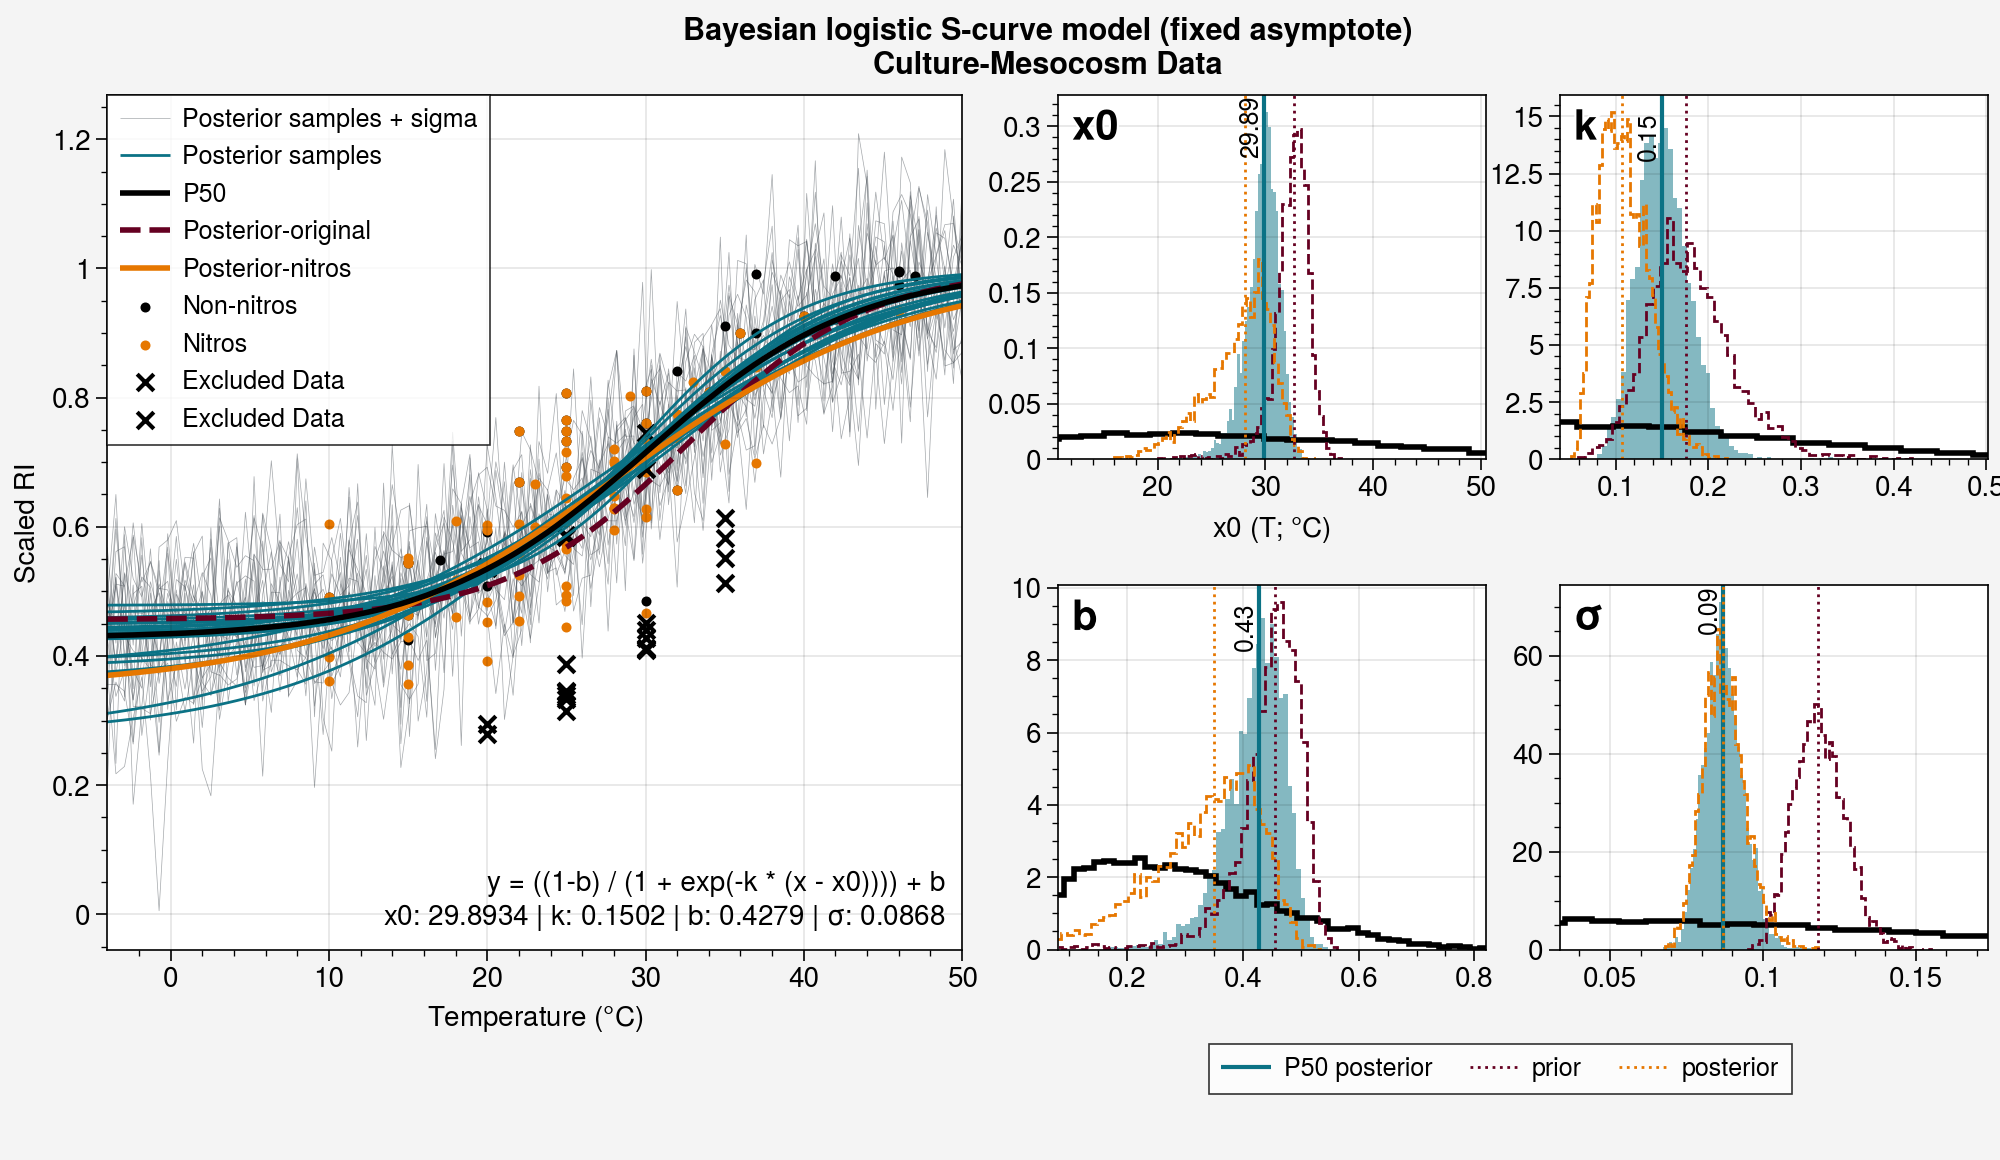

In [33]:
np.random.seed(42)
###  calculate predicted y by randomly sampling from the posterior for 200 samples
x_sample = np.linspace(-4,50, 100)
RI_pred_culture_meso_filtered_samples = []
RI_pred_culture_meso_filtered_noisy_samples = []
for i in range(4000):
        rand_idx = np.random.randint(0, len(x0_post_filtered))
        x0 = x0_post_filtered[i]
        k = k_post_filtered[i]
        b = b_post_filtered[i]
        sigma = sigma_post_filtered[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_culture_meso_filtered_samples.append(y_pred)
        RI_pred_culture_meso_filtered_noisy_samples.append(y_pred_noisy)
RI_pred_culture_meso_filtered_samples = np.array(RI_pred_culture_meso_filtered_samples)
RI_p50_filtered = np.percentile(RI_pred_culture_meso_filtered_samples, 50, axis=0)
RI_p5_filtered = np.percentile(RI_pred_culture_meso_filtered_samples, 5, axis=0)
RI_p95_filtered = np.percentile(RI_pred_culture_meso_filtered_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
## plot random 10 samples from y_pred_noisy
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_filtered_samples))
        ax.plot(x_sample, RI_pred_culture_meso_filtered_noisy_samples[i], color="gray7", lw=0.25,alpha=0.5,zorder=0,
                label="Posterior samples + sigma" if i == 0 else "")
## plot random 100 samples frpm y_pred
for i in range(20):
        rand_idx = np.random.randint(0, len(RI_pred_culture_meso_filtered_samples))
        ax.plot(x_sample, RI_pred_culture_meso_filtered_samples[rand_idx], color="cyan9", lw=1,
                label="Posterior samples" if i == 0 else "",zorder=1)

culture_mesocosm_data_nonNitros = culture_meso_df[culture_meso_df['Temperature']<50][
        culture_meso_df['GTDB_family']!='f__Nitrosopumilaceae'][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
culture_mesocosm_data_nitros = culture_meso_df[culture_meso_df['Temperature']<50][
        culture_meso_df['GTDB_family'].isin(['f__Nitrosopumilaceae','mesocosm'])][culture_meso_df['Source']!='Verma et al. (2024) Biogeosciences']
culture_mesocosm_excluded = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['Source']=='Verma et al. (2024) Biogeosciences']
        
plot_x = culture_mesocosm_data_nonNitros['Temperature']
plot_y = culture_mesocosm_data_nonNitros['scaledRI']
ax.scatter(plot_x, plot_y, label="Non-nitros", color="black", m = '.')

plot_x = culture_mesocosm_data_nitros['Temperature']
plot_y = culture_mesocosm_data_nitros['scaledRI']
ax.scatter(plot_x, plot_y, label="Nitros", color="yellow9", m = '.')

plot_x = culture_mesocosm_excluded['Temperature']
plot_y = culture_mesocosm_excluded['scaledRI']
ax.scatter(plot_x, plot_y, label="Excluded Data", color="k", m = 'x')

ax.plot(x_sample, RI_p50_filtered, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5, RI_p95, color="cyan9", alpha=0.2, label="P5-P95")
plot_excluded_data = culture_mesocosm_excluded
plot_x = plot_excluded_data['Temperature']
plot_y = plot_excluded_data['TEX86']
ax.scatter(plot_x, plot_y, label="Excluded Data", color="k", m = 'x')


ax = axs[1]
ax.format(ultitle="x0")
### plot prior of x2 as normal(0,50)
# Define the normal(20, 20) distribution truncated at -4
mu, sigma = 20, 20   # Mean and standard deviation
lower, upper = -4, np.inf  # Truncation bounds

# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma

# Sample from the truncated normal distribution
x0_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(x0_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_x0_filtered = np.percentile(x0_post_filtered,50)
ax.axvline(p50_x0_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0_filtered, hist_height,f"{p50_x0_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
hist_ = ax.hist(x0_post, bins=50, color='maroon', lw=1, ls='--', label="x0", density=True, histtype='step')
p50_x0 = np.percentile(x0_post,50)
ax.axvline(p50_x0, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(x0_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="x0", density=True, histtype='step')
p50_x0_nitros = np.percentile(x0_post_nitros,50)
ax.axvline(p50_x0_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

ax = axs[2]
ax.format(ultitle="k")
### plot prior of k as normal(0,1)
k_prior = np.random.normal(0, 0.25, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(k_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_k_filtered = np.percentile(k_post_filtered,50)
ax.axvline(p50_k_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_k_filtered, hist_height,f"{p50_k_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
ax.hist(k_post, bins=50, color='maroon', lw=1, ls='--', label="k", density=True, histtype='step')
p50_k = np.percentile(k_post,50)
ax.axvline(p50_k, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(k_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="k", density=True, histtype='step')
p50_k_nitros = np.percentile(k_post_nitros,50)
ax.axvline(p50_k_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

ax = axs[3]
ax.format(ultitle="b")
### plot prior of k as beta(2,5)
b_prior = np.random.beta(2, 5, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(b_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_b_filtered = np.percentile(b_post_filtered,50)
ax.axvline(p50_b_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_b_filtered, hist_height,f"{p50_b_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
ax.hist(b_post, bins=50, color='maroon', lw=1, ls='--', label="b", density=True, histtype='step')
p50_b = np.percentile(b_post,50)
ax.axvline(p50_b, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(b_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="b", density=True, histtype='step')
p50_b_nitros = np.percentile(b_post_nitros,50)
ax.axvline(p50_b_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

ax = axs[4]
ax.format(ultitle=f"$\sigma$")
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.1   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)

### posterior filtered
ax.hist(sigma_post_filtered, bins=50, color='cyan9', label="sigma", density=True, alpha=0.5)
p50_sigma_filtered = np.percentile(sigma_post_filtered,50)
ax.axvline(p50_sigma_filtered, color='cyan9', label="P50-filtered")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma_filtered, hist_height,f"{p50_sigma_filtered:.2f}", ha="right", va="top",
        rotation=90,)

### posterior original
ax.hist(sigma_post, bins=50, color='maroon', lw=1, ls='--', label="sigma", density=True, histtype='step')
p50_sigma = np.percentile(sigma_post,50)
ax.axvline(p50_sigma, color='maroon', label="P50-original", lw=1, ls=':')

### posterior nitros
ax.hist(sigma_post_nitros, bins=50, color='yellow9', lw=1, ls='--', label="sigma", density=True, histtype='step')
p50_sigma_nitros = np.percentile(sigma_post_nitros,50)
ax.axvline(p50_sigma_nitros, color='yellow9', label="P50-nitros", lw=1, ls=':')

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nCulture-Mesocosm Data',
           titleweight='bold',titlesize=15,
           fontsize=10)

### add equation text to the plot
ax = axs[0]
x0_p50_filtered = np.percentile(x0_post_filtered,50)
k_p50_filtered = np.percentile(k_post_filtered,50)
b_p50_filtered = np.percentile(b_post_filtered,50)
sigma_p50_filtered = np.percentile(sigma_post_filtered,50)
eqn_text = f"y = ((1-b) / (1 + exp(-k * (x - x0)))) + b"
ax.text(0.98,0.02,f'{eqn_text}\nx0: {x0_p50_filtered:.4f} | k: {k_p50_filtered:.4f} | b: {b_p50_filtered:.4f} | $\sigma$: {sigma_p50_filtered:.4f}',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=10, color='k')

### limit xlim to be min-max of posterior of each params
params = [x0_post_filtered,k_post_filtered,b_post_filtered,sigma_post_filtered]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.5,np.max(params[i-1])*1.5])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])


### plot posterior curve of the original data
y_original = ((1-b_p50) / (1 + np.exp(-k_p50 * (x_sample - x0_p50)))) + b_p50
ax.plot(x_sample, y_original, color="maroon", lw=2, ls='--', label="Posterior-original",zorder=1)

### plot posterior curve of the filtered nitros only
y_nitros = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (x_sample - x0_p50_nitros)))) + b_p50_nitros
ax.plot(x_sample, y_nitros, color="yellow9", lw=2, label="Posterior-nitros",zorder=1)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, loc='ul', fontsize=8,ncols=1,)

In [34]:
culture_mesocosm_data['pred_scaledRI_culture_meso'] = ((1-b_p50) / (1 + np.exp(-k_p50 * (culture_mesocosm_data['Temperature'] - x0_p50)))) + b_p50
culture_mesocosm_data['scaledRI_residual_culture_meso'] = culture_mesocosm_data['scaledRI'] - culture_mesocosm_data['pred_scaledRI_culture_meso']

culture_mesocosm_data_nitros['pred_scaledRI_culture_meso_nitros'] = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (culture_mesocosm_data_nitros['Temperature'] - x0_p50_nitros)))) + b_p50_nitros
culture_mesocosm_data_nitros['scaledRI_residual_culture_meso_nitros'] = culture_mesocosm_data_nitros['scaledRI'] - culture_mesocosm_data_nitros['pred_scaledRI_culture_meso_nitros']

culture_mesocosm_data_filtered['pred_scaledRI_culture_meso_filtered'] = ((1-b_p50_filtered) / (1 + np.exp(-k_p50_filtered * (culture_mesocosm_data_filtered['Temperature'] - x0_p50_filtered)))+ b_p50_filtered)
culture_mesocosm_data_filtered['scaledRI_residual_culture_meso_filtered'] = culture_mesocosm_data_filtered['scaledRI'] - culture_mesocosm_data_filtered['pred_scaledRI_culture_meso_filtered']


/tmp/ipykernel_114955/3195506909.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  culture_mesocosm_data['pred_scaledRI_culture_meso'] = ((1-b_p50) / (1 + np.exp(-k_p50 * (culture_mesocosm_data['Temperature'] - x0_p50)))) + b_p50
/tmp/ipykernel_114955/3195506909.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  culture_mesocosm_data['scaledRI_residual_culture_meso'] = culture_mesocosm_data['scaledRI'] - culture_mesocosm_data['pred_scaledRI_culture_meso']


In [39]:
coretop_da

,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,scaledRI_mean,...,gdgt23ratio_count,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc
0,-77.875,-40.375,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,0.509982,...,1.0,1.502839,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611
1,-77.375,-158.375,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,0.438075,...,1.0,2.833333,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971
2,-77.125,-45.375,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,0.410931,...,1.0,1.824832,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631
3,-76.625,-35.375,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,0.433342,...,1.0,2.066396,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971
4,-76.375,-33.875,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,0.447518,...,1.0,2.040640,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,84.875,40.625,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,0.459150,...,1.0,4.516129,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159
1475,86.625,152.125,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,0.382600,...,1.0,21.272727,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909
1476,86.875,-146.125,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,0.399850,...,1.0,9.555556,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321
1477,87.125,104.625,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,0.433075,...,1.0,2.870370,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211


## 4.2 Layer 2: Update the S-Curve using culture-meso posteriors

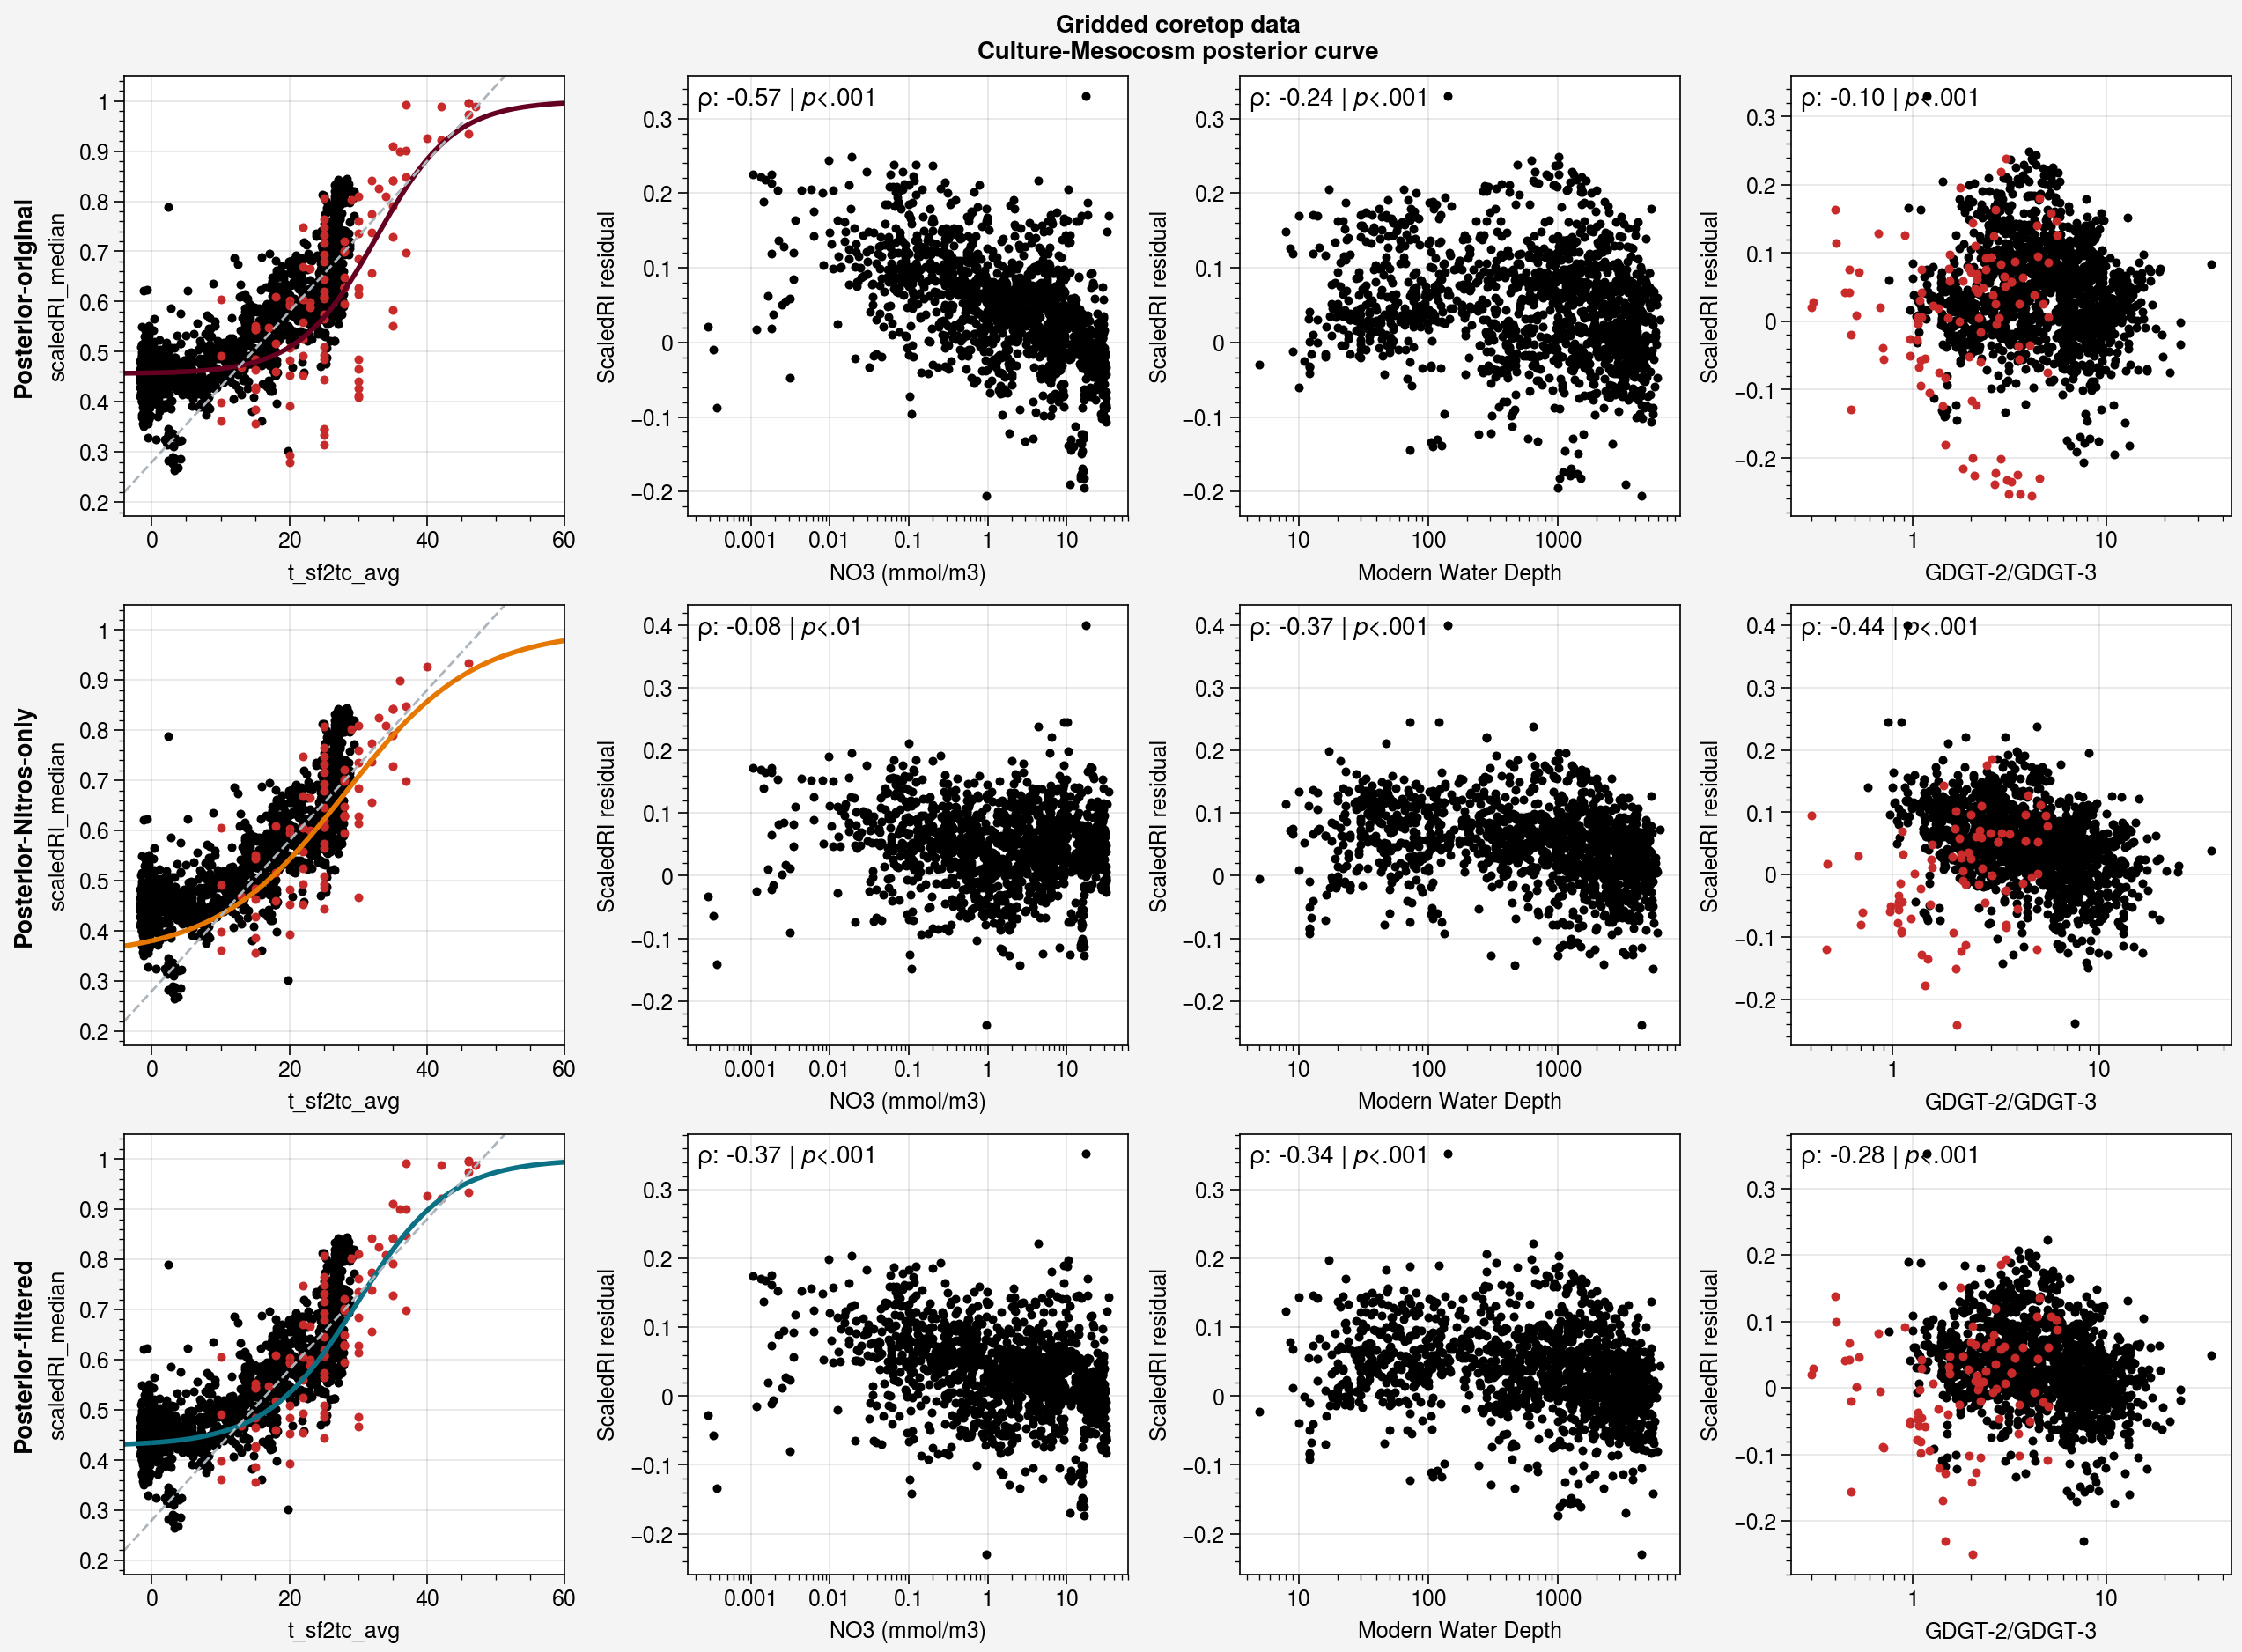

In [42]:
x_sample = np.linspace(-4,60, 100)

coretop_da['pred_scaledRI_culture_meso'] = ((1-b_p50) / (1 + np.exp(-k_p50 * (coretop_da['t_sf2tc_avg'] - x0_p50)))) + b_p50
coretop_da['scaledRI_residual_culture_meso'] = coretop_da['scaledRI_median'] - coretop_da['pred_scaledRI_culture_meso']
coretop_da['pred_scaledRI_culture_meso_nitros'] = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (coretop_da['t_sf2tc_avg'] - x0_p50_nitros)))) + b_p50_nitros
coretop_da['scaledRI_residual_culture_meso_nitros'] = coretop_da['scaledRI_median'] - coretop_da['pred_scaledRI_culture_meso_nitros']
coretop_da['pred_scaledRI_culture_meso_filtered'] = ((1-b_p50_filtered) / (1 + np.exp(-k_p50_filtered * (coretop_da['t_sf2tc_avg'] - x0_p50_filtered)))+ b_p50_filtered)
coretop_da['scaledRI_residual_culture_meso_filtered'] = coretop_da['scaledRI_median'] - coretop_da['pred_scaledRI_culture_meso_filtered']
plot_data = coretop_da[coretop_da['gdgt23ratio_median']<50]

fig, axs = plot.subplots(ncols=4,nrows=3,share=0)
axs.format(
    suptitle='Gridded coretop data\nCulture-Mesocosm posterior curve',
    rowlabels=['Posterior-original','Posterior-Nitros-only','Posterior-filtered'],
)

ax = axs[0,0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
### plot culture-mesocosm posterior curve - original
y_original = ((1-b_p50) / (1 + np.exp(-k_p50 * (x_sample - x0_p50))) + b_p50)
ax.plot(x_sample, y_original, color="maroon", lw=2, label="Posterior-original",zorder=1)

plot_x = culture_mesocosm_data['Temperature']
plot_y = culture_mesocosm_data['scaledRI']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='culture-mesocosm')

ax = axs[0,1]
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='NO3 (mmol/m3)',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['no3_sf2tc_avg','scaledRI_residual_culture_meso']].dropna()
reg_x = reg_data['no3_sf2tc_avg']
reg_y = reg_data['scaledRI_residual_culture_meso']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[0,2]
plot_x = plot_data['modernWaterDepth_mean']
plot_y = plot_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(
        xlabel='Modern Water Depth',
        ylabel='ScaledRI residual',
        xscale='log'
)
### spearman rho and pval
reg_data = plot_data[['modernWaterDepth_mean','scaledRI_residual_culture_meso']].dropna()
reg_x = reg_data['modernWaterDepth_mean']
reg_y = reg_data['scaledRI_residual_culture_meso']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[0,3]
plot_x = plot_data['gdgt23ratio_median']
plot_y = plot_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='GDGT-2/GDGT-3',ylabel='ScaledRI residual',
          xscale='log'
          )
### spearman rho and pval
reg_data = plot_data[['gdgt23ratio_median','scaledRI_residual_culture_meso']].dropna()
reg_x = reg_data['gdgt23ratio_median']
reg_y = reg_data['scaledRI_residual_culture_meso']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')
### plot culture
plot_x = culture_mesocosm_data['gdgt23ratio']
plot_y = culture_mesocosm_data['scaledRI_residual_culture_meso']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='culture-mesocosm')
############################################################################################################
### plot for nitros-only cases
ax = axs[1,0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
### plot culture-mesocosm posterior curve - nitros-only
y_nitros = ((1-b_p50_nitros) / (1 + np.exp(-k_p50_nitros * (x_sample - x0_p50_nitros))) + b_p50_nitros)
ax.plot(x_sample, y_nitros, color="yellow9", lw=2, label="Posterior-nitros",zorder=1)
plot_x = culture_mesocosm_data_nitros['Temperature']
plot_y = culture_mesocosm_data_nitros['scaledRI']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='culture-mesocosm')

ax = axs[1,1]
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='NO3 (mmol/m3)',ylabel='ScaledRI residual',
                xscale='log')

### spearman rho and pval
reg_data = plot_data[['no3_sf2tc_avg','scaledRI_residual_culture_meso_nitros']].dropna()
reg_x = reg_data['no3_sf2tc_avg']
reg_y = reg_data['scaledRI_residual_culture_meso_nitros']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[1,2]
plot_x = plot_data['modernWaterDepth_mean']
plot_y = plot_data['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='Modern Water Depth',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['modernWaterDepth_mean','scaledRI_residual_culture_meso_nitros']].dropna()
reg_x = reg_data['modernWaterDepth_mean']
reg_y = reg_data['scaledRI_residual_culture_meso_nitros']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[1,3]
plot_x = plot_data['gdgt23ratio_median']
plot_y = plot_data['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='GDGT-2/GDGT-3',ylabel='ScaledRI residual',
          xscale='log'
          )
### spearman rho and pval
reg_data = plot_data[['gdgt23ratio_median','scaledRI_residual_culture_meso_nitros']].dropna()
reg_x = reg_data['gdgt23ratio_median']
reg_y = reg_data['scaledRI_residual_culture_meso_nitros']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')
### plot culture
plot_x = culture_mesocosm_data_nitros['gdgt23ratio']
plot_y = culture_mesocosm_data_nitros['scaledRI_residual_culture_meso_nitros']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='culture-mesocosm')

############################################################################################################
ax = axs[2,0]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['scaledRI_median']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
### plot culture-mesocosm posterior curve - filtered
y_original = ((1-b_p50_filtered) / (1 + np.exp(-k_p50_filtered * (x_sample - x0_p50_filtered))) + b_p50_filtered)
ax.plot(x_sample, y_original, color="cyan9", lw=2, label="Posterior-filtered",zorder=1)

plot_x = culture_mesocosm_data_filtered['Temperature']
plot_y = culture_mesocosm_data_filtered['scaledRI']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='culture-mesocosm')

ax = axs[2,1]
plot_x = plot_data['no3_sf2tc_avg']
plot_y = plot_data['scaledRI_residual_culture_meso_filtered']
# ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
m = ax.scatter(plot_x,plot_y,c='k',m='.',label='gridded coretop')
ax.format(xlabel='NO3 (mmol/m3)',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['no3_sf2tc_avg','scaledRI_residual_culture_meso_filtered']].dropna()
reg_x = reg_data['no3_sf2tc_avg']
reg_y = reg_data['scaledRI_residual_culture_meso_filtered']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[2,2]
plot_x = plot_data['modernWaterDepth_mean']
plot_y = plot_data['scaledRI_residual_culture_meso_filtered']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='Modern Water Depth',ylabel='ScaledRI residual',
          xscale='log')
### spearman rho and pval
reg_data = plot_data[['modernWaterDepth_mean','scaledRI_residual_culture_meso_filtered']].dropna()
reg_x = reg_data['modernWaterDepth_mean']
reg_y = reg_data['scaledRI_residual_culture_meso_filtered']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

ax = axs[2,3]
plot_x = plot_data['gdgt23ratio_median']
plot_y = plot_data['scaledRI_residual_culture_meso_filtered']
ax.scatter(plot_x,plot_y,m='.',color='k',label='gridded coretop')
ax.format(xlabel='GDGT-2/GDGT-3',ylabel='ScaledRI residual',
          xscale='log'
          )
### spearman rho and pval
reg_data = plot_data[['gdgt23ratio_median','scaledRI_residual_culture_meso_filtered']].dropna()
reg_x = reg_data['gdgt23ratio_median']
reg_y = reg_data['scaledRI_residual_culture_meso_filtered']
rho, pval = spearmanr(reg_x,reg_y)
ax.text(0.02,0.98,f"$\\rho$: {rho:.2f} | {label_pvalues(pval)}",
        ha='left', va='top', transform=ax.transAxes,
        fontsize=10, color='k')

### plot culture
plot_x = culture_mesocosm_data_filtered['gdgt23ratio']
plot_y = culture_mesocosm_data_filtered['scaledRI_residual_culture_meso_filtered']
ax.scatter(plot_x,plot_y,m='.',color='red9',label='culture-mesocosm-filtered')

#### plot Schouten et al 2002 linear fit
pred_schouten2002 = predictTEXfromSST(x_sample,method_name='schouten2002')
axs[:,0].plot(x_sample, pred_schouten2002, color="gray5", lw=1, 
              label="Schouten et al. 2002",zorder=1,ls='--')
axs[:,0].format(ymax=1.05)

In [ ]:
# Prepare core-top data
coretop_data = coretop_gridded_df.dropna(subset=['t_sf2tc_avg','scaledRI_median']).reset_index(drop=True)

x_coretop = coretop_data['t_sf2tc_avg'].astype(float).tolist()
y_coretop = coretop_data['scaledRI_median'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_2STD = np.mean(x0_post_filtered), np.std(x0_post_filtered)*2
K_MEAN, K_2STD = np.mean(k_post_filtered), np.std(k_post_filtered)*2
B_MEAN, B_2STD = np.mean(b_post_filtered), np.std(b_post_filtered)*2

# Define Stan data dictionary
coretop_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "X0_MEAN": X0_MEAN,
    "X0_2STD": X0_2STD,
    "K_MEAN": K_MEAN,
    "K_2STD": K_2STD,
    "B_MEAN": B_MEAN,
    "B_2STD": B_2STD
}

# Compile and sample from the core-top model
coretop_model = CmdStanModel(stan_file=os.path.join(stan_models_path, 
                                                    "coretop_regression_post_stats.stan"))

coretop_fit = coretop_model.sample(data=coretop_stan_data, 
                                   chains=4, 
                                   iter_warmup=500, 
                                   iter_sampling=1000, 
                                   parallel_chains=4,
                                #    show_console=True,
                                   seed=42)

# Check available variables before extracting
print("Available variables:", coretop_fit.stan_variables().keys())

# Extract posterior samples 
x0_coretop_post_stats = coretop_fit.stan_variable("x0")
k_coretop_post_stats = coretop_fit.stan_variable("k")
b_coretop_post_stats = coretop_fit.stan_variable("b")
sigma_coretop_post_stats = coretop_fit.stan_variable("sigma")

10:31:46 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█▏        | 00:00 Iteration:    1 / 1500 [  0%]  (Warmup)
chain 1 |██▎       | 00:00 Iteration:  200 / 1500 [ 13%]  (Warmup)
chain 1 |███▌      | 00:00 Iteration:  400 / 1500 [ 26%]  (Warmup)
chain 1 |█████▎    | 00:00 Iteration:  600 / 1500 [ 40%]  (Sampling)
chain 1 |██████▍   | 00:00 Iteration:  800 / 1500 [ 53%]  (Sampling)


chain 1 |███████▋  | 00:00 Iteration: 1000 / 1500 [ 66%]  (Sampling)

chain 1 |████████▊ | 00:00 Iteration: 1200 / 1500 [ 80%]  (Sampling)
chain 1 |██████████| 00:01 Iteration: 1400 / 1500 [ 93%]  (Sampling)












chain 1 |██████████| 00:01 Sampling completed                       
chain 2 |██████████| 00:01 Sampling completed                       
chain 3 |██████████| 00:01 Sampling completed                       
chain 4 |██████████| 00:01 Sampling completed                       


10:31:48 - cmdstanpy - INFO - CmdStan done processing.
10:31:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_post_stats.stan', line 32, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_post_stats.stan', line 32, column 2 to column 35)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_post_stats.stan', line 32, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_post_stats.stan', line 32, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_post_stats.stan', line 32, column 2 to column 35)
Consider re-running with show_console=True if the above output is unclear!



Available variables: dict_keys(['x0', 'k', 'b', 'sigma'])


<a list of 1 Line2D objects>

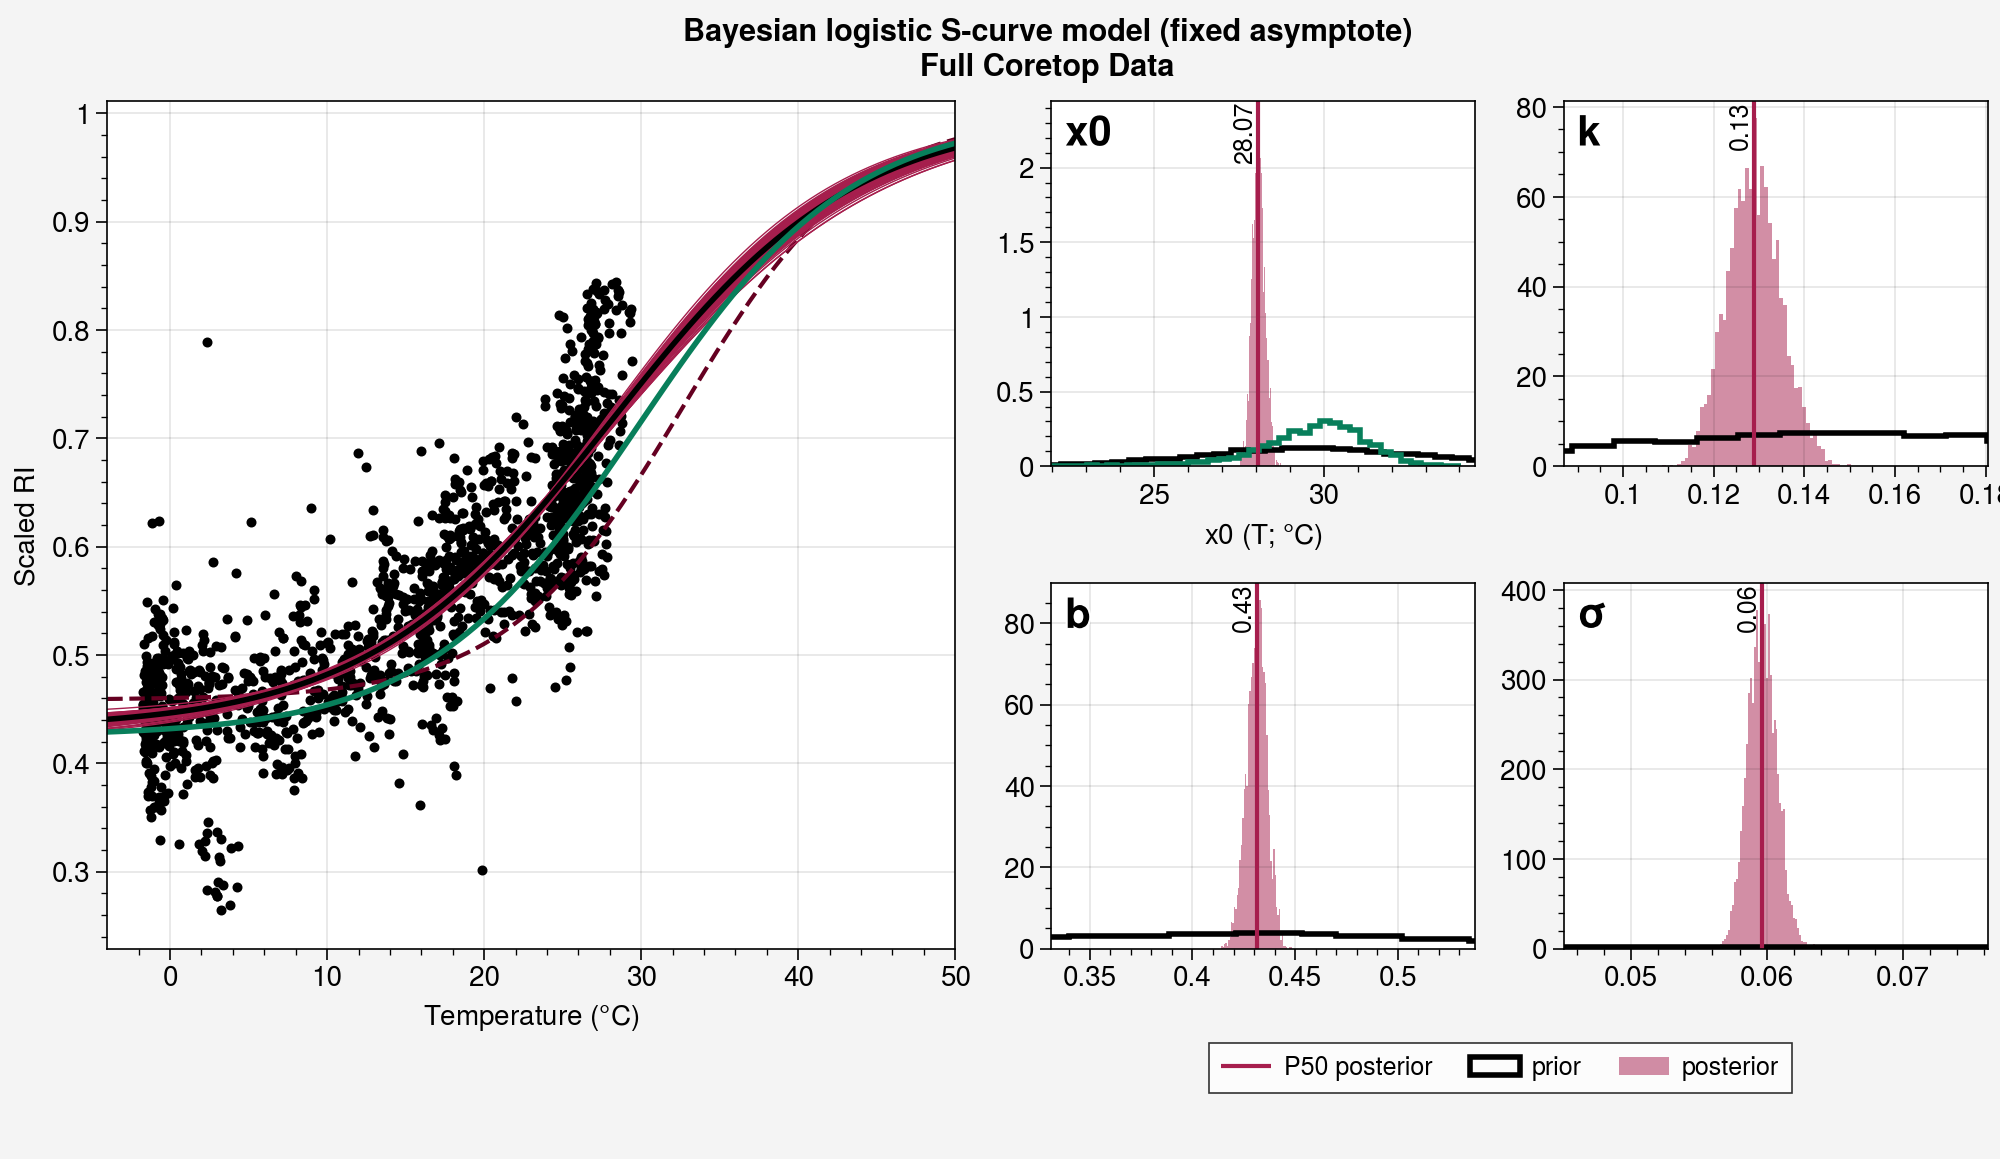

In [ ]:
x_sample = np.linspace(-4,50, 100)
# Compute posterior means and standard deviations
X0_MEAN, X0_2STD = np.mean(x0_post_filtered), np.std(x0_post_filtered)*2
K_MEAN, K_2STD = np.mean(k_post_filtered), np.std(k_post_filtered)*2
B_MEAN, B_2STD = np.mean(b_post_filtered), np.std(b_post_filtered)*2

X0_MEDIAN = np.median(x0_post_filtered)
K_MEDIAN = np.median(k_post_filtered)
B_MEDIAN = np.median(b_post_filtered)

###  calculate predicted y by randomly sampling from the posterior for 200 samples
RI_pred_coretop_full_post_stats_samples = []
RI_pred_coretop_full_post_stats_noisy_samples = []
for i in range(4000):
        x0 = x0_coretop_post_stats[i]
        k = k_coretop_post_stats[i]
        b = b_coretop_post_stats[i]
        sigma = sigma_coretop_post_stats[i]
        # Calculate predicted y using the logistic function
        y_pred = ((1-b) / (1 + np.exp(-k * (x_sample - x0)))) + b
        y_pred_noisy = np.random.normal(y_pred, sigma)
        # Append the predicted y to the list
        RI_pred_coretop_full_post_stats_samples.append(y_pred)
        RI_pred_coretop_full_post_stats_noisy_samples.append(y_pred_noisy)
RI_pred_coretop_full_post_stats_samples = np.array(RI_pred_coretop_full_post_stats_samples)
RI_gridded_coretop_p50 = np.percentile(RI_pred_coretop_full_post_stats_samples, 50, axis=0)
RI_gridded_coretop_p5 = np.percentile(RI_pred_coretop_full_post_stats_samples, 5, axis=0)
RI_gridded_coretop_p95 = np.percentile(RI_pred_coretop_full_post_stats_samples, 95, axis=0)
RI_gridded_coretop_p0 = np.percentile(RI_pred_coretop_full_post_stats_samples, 0, axis=0)
RI_gridded_coretop_p100 = np.percentile(RI_pred_coretop_full_post_stats_samples, 100, axis=0)
RI_gridded_coretop_p5_noisy = np.percentile(RI_pred_coretop_full_post_stats_noisy_samples, 5, axis=0)
RI_gridded_coretop_p95_noisy = np.percentile(RI_pred_coretop_full_post_stats_noisy_samples, 95, axis=0)
# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)
ax = axs[0]
# ## plot random 10 samples from y_pred_noisy
# for i in range(20):
#         rand_idx = np.random.randint(0, len(RI_pred_coretop_full_post_stats_noisy_samples))
#         ax.plot(x_sample, RI_pred_coretop_full_post_stats_noisy_samples[rand_idx], color="gray7", lw=0.5,alpha=0.5)
## plot random 100 samples frpm y_pred
for i in range(100):
        rand_idx = np.random.randint(0, len(RI_pred_coretop_full_post_stats_samples))
        ax.plot(x_sample, RI_pred_coretop_full_post_stats_samples[rand_idx], color="pink9", lw=0.5)
ax.scatter(x_coretop, y_coretop, label="Data", color="black", m = '.')
ax.plot(x_sample, RI_gridded_coretop_p50, color="k", label="P50",lw=2)
# ax.fill_between(x_sample, RI_p5_noisy, RI_p95_noisy, color="pink9", alpha=0.75, label="P5-P95")


### plot kde of the posterior samples
ax = axs[1]
### plot prior of x0 as normal(X0_MEAN,X0_STD)
x0_prior = np.random.normal(X0_MEAN, X0_2STD, 10000)
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### plot culture-mesocosm posterior
ax.hist(x0_post_filtered, bins=50, color='teal9', lw=2, label="x0", density=True, histtype='step')

### posterior
hist_ = ax.hist(x0_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="x0", density=True)
p50_coretop_x0 = np.percentile(x0_coretop_post_stats,50)
ax.axvline(p50_coretop_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_x0, hist_height,f"{p50_coretop_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as normal(K_MEAN,K_3STD)
k_prior = np.random.normal(K_MEAN, K_2STD, 10000)
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="k", density=True)
p50_coretop_k = np.percentile(k_coretop_post_stats,50)
ax.axvline(p50_coretop_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_k, hist_height,f"{p50_coretop_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as normal(B_MEAN, B_3STD)
b_prior = np.random.normal(B_MEAN, B_2STD, 10000)
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="b", density=True)
p50_coretop_b = np.percentile(b_coretop_post_stats,50)
ax.axvline(p50_coretop_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_b, hist_height,f"{p50_coretop_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]
### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.5   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_coretop_post_stats, bins=50, color='pink9', alpha=0.5, label="sigma", density=True)
p50_coretop_sigma = np.percentile(sigma_coretop_post_stats,50)
ax.axvline(p50_coretop_sigma, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_coretop_sigma, hist_height,f"{p50_coretop_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_coretop_post_stats,k_coretop_post_stats,b_coretop_post_stats,sigma_coretop_post_stats]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1])*0.8,np.max(params[i-1])*1.2])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nFull Coretop Data',
           titleweight='bold',titlesize=15,
           fontsize=10)


#### plot a curve based on p50_coretop_x0, p50_coretop_k, p50_coretop_b, p50_coretop_sigma
y_pred_filtered = ((1-p50_b_filtered) / (1 + np.exp(-p50_k_filtered * (x_sample - p50_x0_filtered)))) + p50_b_filtered
axs[0].plot(x_sample, y_pred_filtered, color="teal9", lw=2, label="P50 posterior")

### plot posterior curve of the original data
y_original = ((1-b_p50) / (1 + np.exp(-k_p50 * (x_sample - x0_p50))) + b_p50)
axs[0].plot(x_sample, y_original, color="maroon", lw=1.5, ls='--', label="Posterior-original",zorder=1)

In [ ]:
### calculate RI_residuals from the p50 of the posterior samples
coretop_df = reg_data[reg_data['datatype']=='coretop'].copy()
coretop_df['Latitude'] = coretop_df['Latitude'].astype(float)
coretop_df['Longitude'] = coretop_df['Longitude'].astype(float)
def get_pred_RI_culture_meso(temp):
    return ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (temp - X0_MEDIAN)))) + B_MEDIAN
coretop_df['pred_RI_culture_meso'] = coretop_data['Temperature'].apply(get_pred_RI_culture_meso)
coretop_df['RI_residuals'] = coretop_df['scaledRI'] - coretop_df['pred_RI_culture_meso']


plot_data = coretop_df[coretop_df['gdgt23ratio']<50].dropna(subset=['RI_residuals'])

array = [
    [1,0],
    [2,3],
    [4,5]
]
fig, axs = plot.subplots(array,proj=('eck3',None),width=7,
                         hratios=(0.5,1,1),
                         share=0)
axs.format(
    land=True,landcolor='gray5',landzorder=0,
    coast=True,coastzorder=0,
)

ax = axs[0]
plot_lon = plot_data['Longitude']
plot_lat = plot_data['Latitude']
plot_RI_residuals = plot_data['RI_residuals']
ax.scatter(plot_lon, plot_lat,c=plot_RI_residuals,cmap='balance')

ax = axs[1]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
plot_c = plot_data['gdgt23ratio']
m = ax.scatter(plot_x, plot_y, c='k', cmap='matter', label=name, s=10)
# ax.colorbar(m, label='GDGT-2/3 ratio',loc='ul')
x_sample = np.linspace(-4,50, 100)
y_pred = ((1-B_MEDIAN) / (1 + np.exp(-K_MEDIAN * (x_sample - X0_MEDIAN)))) + B_MEDIAN
ax.plot(x_sample, y_pred, color="teal9", lw=2, label="Culture-Mesocosm Model")
h, l = ax.get_legend_handles_labels()
ax.legend(h, ['Culture-Mesocosm Model'], loc='lr', fontsize=8,ncols=3,)
### plot previously published calibration curves


ax = axs[2] # plot RI_residuals vs temperature
plot_x = plot_data['Temperature']
plot_y = plot_data['RI_residuals']
ax.scatter(plot_x, plot_y, c='k', s=10)


KeyError: 'datatype'

In [ ]:
import numpy as np
import os
from cmdstanpy import CmdStanModel

# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Define Stan data dictionary (Pass full posteriors)
coretop_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "M": len(x0_post),  # Use all posterior draws
    "x0_post": x0_post.tolist(),
    "k_post": k_post.tolist(),
    "b_post": b_post.tolist()
}

# Compile and sample from the core-top model
coretop_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_regression_kde_inside.stan"))

coretop_full_posterior_fit = coretop_model.sample(
    data=coretop_stan_data,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    parallel_chains=4,
    seed=42
)

# Extract posterior samples from second-layer model
x0_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("x0")
k_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("k")
b_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("b")
sigma_coretop_full_posterior = coretop_full_posterior_fit.stan_variable("sigma")


09:36:21 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_kde_inside.stan to exe file /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_kde_inside
09:36:29 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_kde_inside
09:36:29 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█▊        | 00:00 Iteration:  100 / 1500 [  6%]  (Warmup)


chain 1 |██▉       | 00:00 Iteration:  300 / 1500 [ 20%]  (Warmup)



chain 1 |████▋     | 00:00 Iteration:  501 / 1500 [ 33%]  (Sampling)


chain 1 |█████▉    | 00:00 Iteration:  700 / 1500 [ 46%]  (Sampling)


chain 1 |███████   | 00:00 Iteration:  900 / 1500 [ 60%]  (Sampling)


chain 1 |████████▏ | 00:00 Iteration: 1100 / 1500 [ 73%]  (Sampling)


chain 1 |█████████▍| 00:01 Iteration: 1300 / 1500 [ 86%]  (Sampling)

chain 1 |███████


09:36:30 - cmdstanpy - INFO - CmdStan done processing.
09:36:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_regression_kde_inside.stan', line 34, column 2 to column 61)
Consider re-running wi

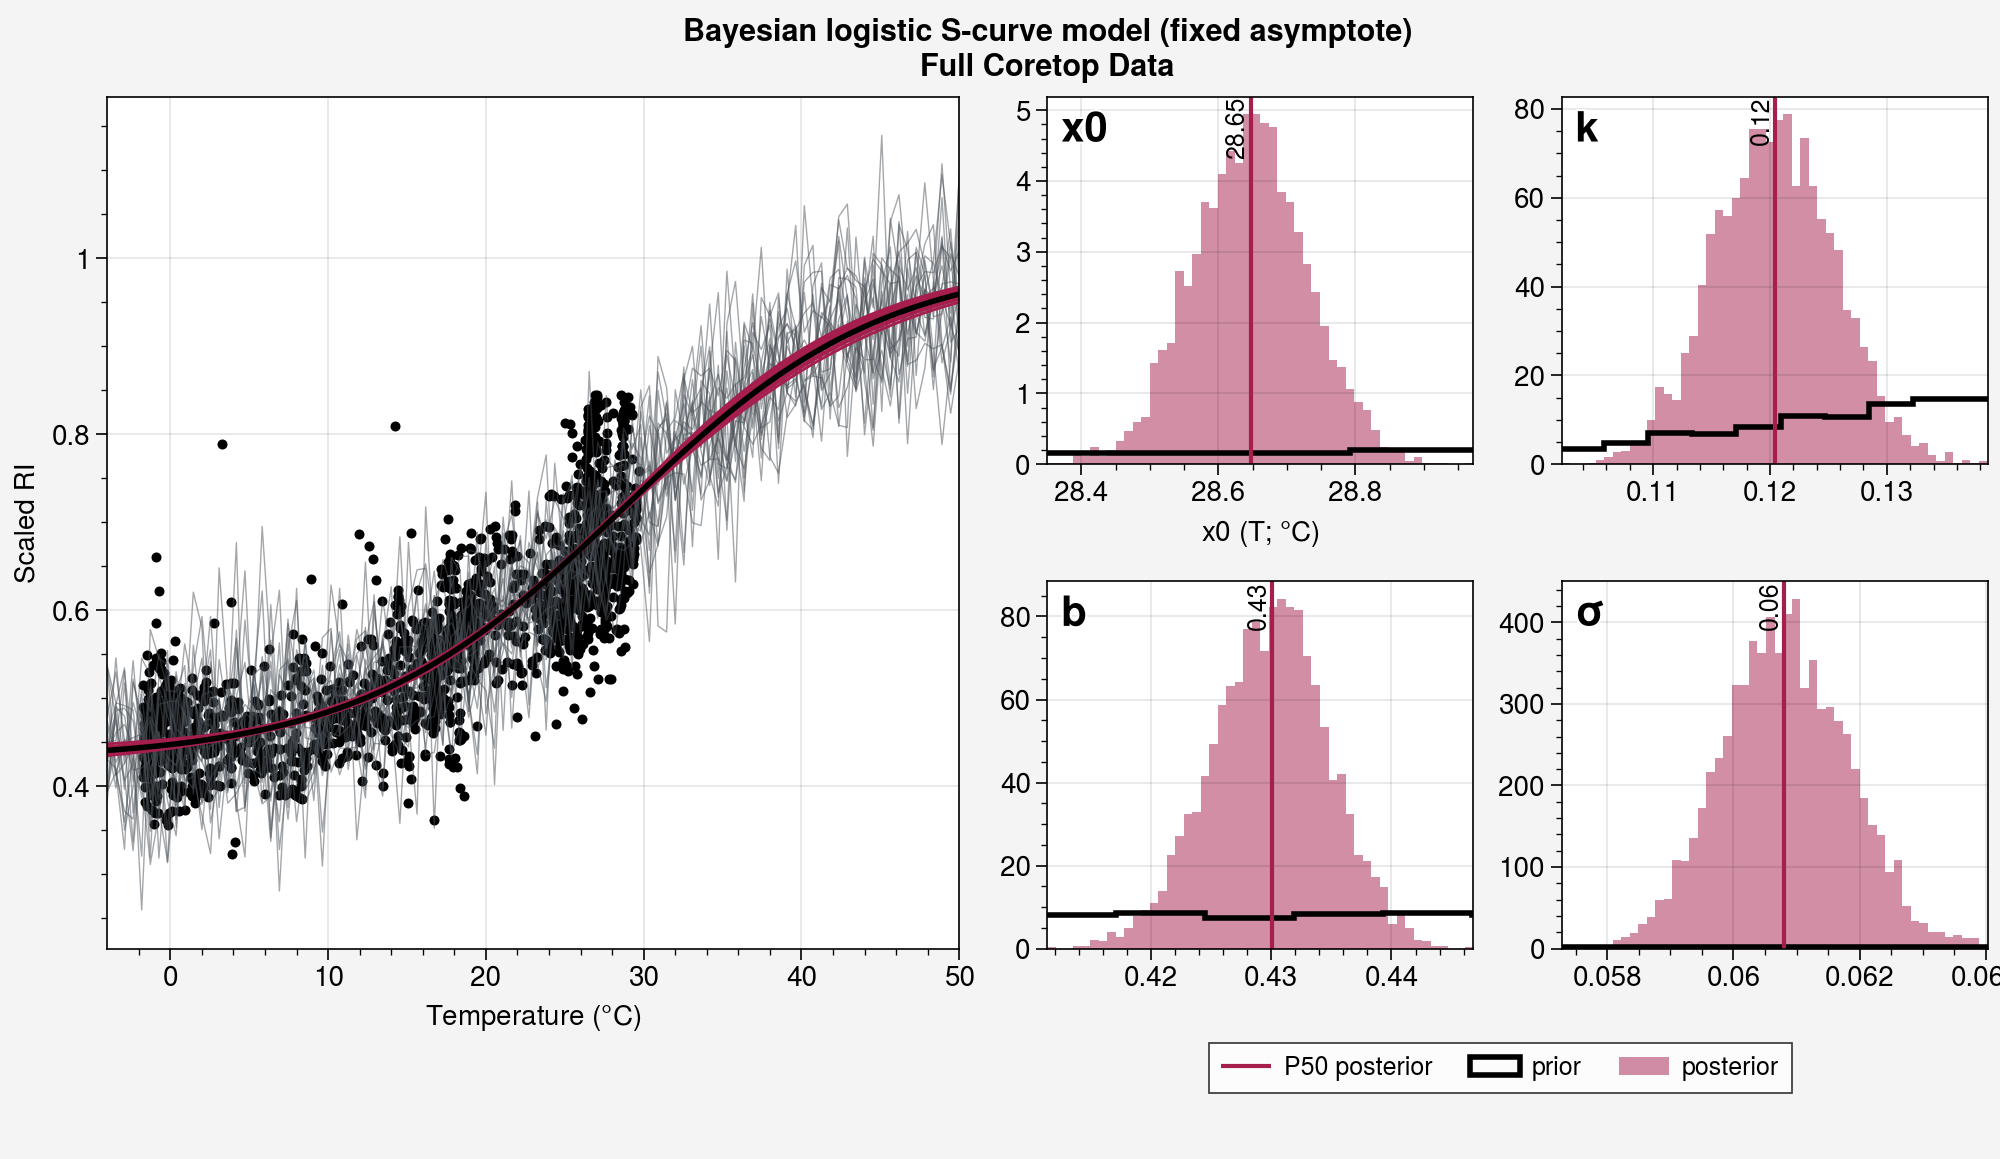

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, gaussian_kde

# Fix the random seed for reproducibility
np.random.seed(42)

# Generate x-values for predictions
x_sample = np.linspace(-4, 50, 100)

# Compute predicted y by randomly sampling from the second-layer posterior
RI_pred_coretop_full_samples = []
RI_pred_coretop_full_noisy_samples = []

for i in range(4000):  
    x0 = x0_coretop_full_posterior[i]
    k = k_coretop_full_posterior[i]
    b = b_coretop_full_posterior[i]
    sigma = sigma_coretop_full_posterior[i]

    # Compute predicted y using logistic function
    y_pred = ((1 - b) / (1 + np.exp(-k * (x_sample - x0)))) + b
    y_pred_noisy = np.random.normal(y_pred, sigma)

    # Store predictions
    RI_pred_coretop_full_samples.append(y_pred)
    RI_pred_coretop_full_noisy_samples.append(y_pred_noisy)

# Convert to NumPy arrays
RI_pred_coretop_full_samples = np.array(RI_pred_coretop_full_samples)
RI_p50 = np.percentile(RI_pred_coretop_full_samples, 50, axis=0)
RI_p5 = np.percentile(RI_pred_coretop_full_samples, 5, axis=0)
RI_p95 = np.percentile(RI_pred_coretop_full_samples, 95, axis=0)

# Plot results
array = [
        [1,1,2,3],
        [1,1,4,5]
]
fig, axs = plot.subplots(array,share=0,
                         width=10)

# === PLOT 1: Predictions & Observations ===
ax = axs[0]

# Plot random 20 samples from y_pred_noisy
for i in range(20):
    rand_idx = np.random.randint(0, len(RI_pred_coretop_full_noisy_samples))
    ax.plot(x_sample, RI_pred_coretop_full_noisy_samples[rand_idx], color="gray7", lw=0.5, alpha=0.5)

# Plot random 20 samples from y_pred
for i in range(20):
    rand_idx = np.random.randint(0, len(RI_pred_coretop_full_samples))
    ax.plot(x_sample, RI_pred_coretop_full_samples[rand_idx], color="pink9", lw=1)

ax.scatter(x_coretop, y_coretop, label="Data", color="black", marker='.')
ax.plot(x_sample, RI_p50, color="k", label="P50", lw=2)
ax.fill_between(x_sample, RI_p5, RI_p95, color="pink9", alpha=0.2, label="P5-P95")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Scaled RI")

### plot kde of the posterior samples
ax = axs[1]
### plot prior of x0 as normal(X0_MEAN,X0_STD)
x0_prior = x0_post
ax.hist(x0_prior, bins=50, color='k', label="x0", density=True, histtype='step',lw=2)

### posterior
hist_ = ax.hist(x0_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="x0", density=True)
p50_x0 = np.percentile(x0_coretop_full_posterior,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
### plot prior of k as k_post from the first layer
k_prior = k_post
ax.hist(k_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)

ax.hist(k_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="k", density=True)
p50_k = np.percentile(k_coretop_full_posterior,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
### plot prior of k as normal(B_MEAN, B_3STD)
b_prior = b_post
ax.hist(b_prior, bins=50, color='k', label="k", density=True, histtype='step',lw=2)
ax.hist(b_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="b", density=True)
p50_b = np.percentile(b_coretop_full_posterior,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")

ax = axs[4]

### plot prior of k as normal(0.05, 0.5) but truncated at 0
# Define the normal(0.05, 0.5) distribution truncated at 0
mu, sigma = 0.05, 0.5   # Mean and standard deviation
lower, upper = 0, np.inf  # Truncation bounds
# Convert bounds to standard normal form (z-scores)
a, b = (lower - mu) / sigma, (upper - mu) / sigma
# Sample from the truncated normal distribution
sigma_prior = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=10000)
# Plot the histogram of the prior
ax.hist(sigma_prior, bins=50, color='k', label="sigma", density=True, histtype='step',lw=2)
ax.hist(sigma_coretop_full_posterior, bins=50, color='pink9', alpha=0.5, label="sigma", density=True)
p50_sigma = np.percentile(sigma_coretop_full_posterior,50)
ax.axvline(p50_sigma, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_sigma, hist_height,f"{p50_sigma:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle=f"$\sigma$")

### limit xlim to be min-max of posterior of each params
params = [x0_coretop_full_posterior,k_coretop_full_posterior,b_coretop_full_posterior,sigma_coretop_full_posterior]
for i in range(1,5):
    axs[i].set_xlim([np.min(params[i-1]),np.max(params[i-1])])
    axs[i].set_ylim([0,axs[i].get_ylim()[1]])

h, l = ax.get_legend_handles_labels()
fig.legend(h, ['P50 posterior','prior','posterior'], loc='b', fontsize=8,ncols=3,
           bbox_to_anchor=(0.75, 0.1), bbox_transform=fig.transFigure,)

axs[0].format(xlabel='Temperature ($\degree$C)',ylabel='Scaled RI',)
axs[1].format(xlabel='x0 (T; $\degree$C)')
axs.format(suptitle='Bayesian logistic S-curve model (fixed asymptote)\nFull Coretop Data',
           titleweight='bold',titlesize=15,
           fontsize=10)


In [ ]:
# Prepare core-top data
coretop_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop')
].dropna(subset=['Temperature', 'scaledRI','gdgt23ratio'])

x_coretop = coretop_data['Temperature'].astype(float).tolist()
x2_coretop = coretop_data['gdgt23ratio'].astype(float).tolist()
y_coretop = coretop_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_STD = np.mean(x0_post), np.std(x0_post)
K_MEAN, K_STD = np.mean(k_post), np.std(k_post)
B_MEAN, B_STD = np.mean(b_post), np.std(b_post)

# Define Stan data dictionary
coretop_combined_stan_data = {
    "N": len(coretop_data),
    "x": x_coretop,
    "y": y_coretop,
    "x2": x2_coretop,
    "X0_MEAN": X0_MEAN,
    "X0_STD": X0_STD,
    "K_MEAN": K_MEAN,
    "K_STD": K_STD,
    "B_MEAN": B_MEAN,
    "B_STD": B_STD
}

# Compile and sample from the core-top model
coretop_combined_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_combined.stan"))

coretop_combined_fit = coretop_combined_model.sample(data=coretop_combined_stan_data, chains=4, iter_warmup=500, iter_sampling=1000, seed=42)

# Check available variables before extracting
print("Available variables:", coretop_fit.stan_variables().keys())

# Extract posterior samples
coretop_combined_x0_post = coretop_combined_fit.stan_variable("x0")
coretop_combined_k_post = coretop_combined_fit.stan_variable("k")
coretop_combined_b_post = coretop_combined_fit.stan_variable("b")
coretop_combined_beta_x2_post = coretop_combined_fit.stan_variable("beta_x2")
coretop_combined_alpha_post = coretop_combined_fit.stan_variable("alpha")

09:36:31 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status






chain 1 |█▊        | 00:01 Iteration:  100 / 1500 [  6%]  (Warmup)



chain 1 |██▎       | 00:03 Iteration:  200 / 1500 [ 13%]  (Warmup)


chain 1 |██▉       | 00:03 Iteration:  300 / 1500 [ 20%]  (Warmup)




chain 1 |███▌      | 00:04 Iteration:  400 / 1500 [ 26%]  (Warmup)
chain 1 |████▋     | 00:05 Iteration:  501 / 1500 [ 33%]  (Sampling)


chain 1 |█████▎    | 00:06 Iteration:  600 / 1500 [ 40%]  (Sampling)


chain 1 |█████▉    | 00:07 Iteration:  700 / 1500 [ 46%]  (Sampling)


chain 1 |██████▍   | 00:08 Iteration:  800 / 1500 [ 53%]  (Sampling)


chain 1 |███████   | 00:09 Iteration:  900 / 1500 [ 60%]  (Sampling)


chain 1 |███████▋  | 00:10 Iteration: 1000 / 1500 [ 66%]  (Sampling)


chain 1 |████████▏ | 00:11 Iteration: 1100 / 1500 [ 73%]  (Sampling)



chain 1 |████████▊ | 00:12 Iteration: 1200 / 1500 [ 80%]  (Sampling)


chain 1 |██████████| 00:14 Sampling completed              


09:36:45 - cmdstanpy - INFO - CmdStan done processing.
09:36:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_combined.stan', line 34, column 2 to column 86)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'coretop_combined.stan', line 34, column 2 to column 86)
Consider re-running with show_console=True if the above output is unclear!



Available variables: dict_keys(['x0', 'k', 'b', 'sigma'])


In [ ]:
# Prepare core-top data
coretop_shallowAOA_data = reg_data[
    (reg_data['QC_flag'] == 'include') &
    (reg_data['Temperature'] < 50) &
    (reg_data['datatype'] == 'coretop') &
    (reg_data['gdgt23ratio'] < 5)
].dropna(subset=['Temperature', 'scaledRI'])

x_coretop_shallowAOA = coretop_shallowAOA_data['Temperature'].astype(float).tolist()
y_coretop_shallowAOA = coretop_shallowAOA_data['scaledRI'].astype(float).tolist()

# Compute posterior means and standard deviations
X0_MEAN, X0_STD = np.mean(x0_post), np.std(x0_post)
K_MEAN, K_STD = np.mean(k_post), np.std(k_post)
B_MEAN, B_STD = np.mean(b_post), np.std(b_post)

# Define Stan data dictionary
coretop_shallowAOA_stan_data = {
    "N": len(coretop_shallowAOA_data),
    "x": x_coretop_shallowAOA,
    "y": y_coretop_shallowAOA,
    "X0_MEAN": X0_MEAN,
    "X0_STD": X0_STD,
    "K_MEAN": K_MEAN,
    "K_STD": K_STD,
    "B_MEAN": B_MEAN,
    "B_STD": B_STD
}

# Compile and sample from the core-top model
coretop_shallowAOA_model = CmdStanModel(stan_file=os.path.join(stan_models_path, "coretop_regression_fullpost.stan"))

coretop_shallowAOA_fit = coretop_shallowAOA_model.sample(data=coretop_shallowAOA_stan_data, chains=4, iter_warmup=500, iter_sampling=1000, seed=42)

# Check available variables before extracting
print("Available variables:", coretop_shallowAOA_fit.stan_variables().keys())

# Extract posterior samples
coretop_shallowAOA_x0_post = coretop_shallowAOA_fit.stan_variable("x0")
coretop_shallowAOA_k_post = coretop_shallowAOA_fit.stan_variable("k")
coretop_shallowAOA_b_post = coretop_shallowAOA_fit.stan_variable("b")


coretop_shallow_AOA_pred_samples = []


ValueError: no such file /home/ronnie-rattan/Documents/GitHub/calRIbaysian/stan_models/coretop_regression_fullpost.stan

In [ ]:
### plot coretop data
fig, axs = plot.subplots(ncols=4,share=0)
ax = axs[0]
ax.scatter(x_coretop, y_coretop, label="Data",m='.',mew=0, color="black")
x_sample = np.linspace(coretop_data['Temperature'].min(), 50, 100)
y_sample_P50 = (1-np.percentile(coretop_b_post,50)) / (1 + np.exp(-np.percentile(coretop_k_post,50) * (x_sample - np.percentile(coretop_x0_post,50))))  + np.percentile(coretop_b_post,50)

### plot posterior samples
for i in range(100):
    y_sample = (1-coretop_b_post[i]) / (1 + np.exp(-coretop_k_post[i] * (x_sample - coretop_x0_post[i])))  + coretop_b_post[i]
    ax.plot(x_sample, y_sample, color='pink5', lw=0.1)

### plot #P50 of the posterior samples
ax.plot(x_sample, y_sample_P50, color='pink9', label="P50", lw=2)

## plot posterior samples as histogram
ax = axs[1]
hist_ = ax.hist(coretop_x0_post, bins=50, color='pink9', alpha=0.5, label="x0")
p50_x0 = np.percentile(coretop_x0_post,50)
ax.axvline(p50_x0, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_x0, hist_height,f"{p50_x0:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="x0")

ax = axs[2]
ax.hist(coretop_k_post, bins=50, color='pink9', alpha=0.5, label="k")
p50_k = np.percentile(coretop_k_post,50)
ax.axvline(p50_k, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_k, hist_height,f"{p50_k:.2f}", ha="right", va="top",
        rotation=90,)
hist_height = ax.get_ylim()[1]
ax.format(ultitle="k")

ax = axs[3]
ax.hist(coretop_b_post, bins=50, color='pink9', alpha=0.5, label="b")
p50_b = np.percentile(coretop_b_post,50)
ax.axvline(p50_b, color='pink9', label="P50")
hist_height = ax.get_ylim()[1]
ax.text(p50_b, hist_height,f"{p50_b:.2f}", ha="right", va="top",
        rotation=90,)
ax.format(ultitle="b")


In [ ]:
### plot culture+mesocosm data and coretop data together
x_sample = np.linspace(-5,50, 100)

fig, axs = plot.subplots(ncols=4,nrows=3,share=0)
axs.format(
    rowlabels=['Culture+Mesocosm','Coretop','Comparison'],
)

ax = axs[0,0]
plot_data = culture_mesocosm_data
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='culture+mesocosm', m='.', mew=0, color='black')
### plot posterior fit
x0_cul_meso_P50 = np.percentile(x0_post,50)
k_cul_meso_P50 = np.percentile(k_post,50)
b_cul_meso_P50 = np.percentile(b_post,50)
y_sample_P50 = (1-b_cul_meso_P50) / (1 + np.exp(-k_cul_meso_P50 * (x_sample - x0_cul_meso_P50)))  + b_cul_meso_P50
ax.plot(x_sample, y_sample_P50, color='teal9', label="P50", lw=2)

ax = axs[1,0]
plot_data = coretop_data[coretop_data['gdgt23ratio']<5]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='coretop', m='.', mew=0, color='black')
plot_data = coretop_data[coretop_data['gdgt23ratio']>5]
plot_x = plot_data['Temperature']
plot_y = plot_data['scaledRI']
ax.scatter(plot_x, plot_y, label='coretop', m='o', facecolor='none', mec='gray')
### plot posterior fit
x0_coretop_P50 = np.percentile(coretop_x0_post,50)
k_coretop_P50 = np.percentile(coretop_k_post,50)
b_coretop_P50 = np.percentile(coretop_b_post,50)
y_coretop_sample_P50 = (1-b_coretop_P50) / (1 + np.exp(-k_coretop_P50 * (x_sample - x0_coretop_P50)))  + b_coretop_P50
ax.plot(x_sample, y_coretop_sample_P50, color='pink9', label="P50", lw=2)

####################################################################################
### plot posterior fit
x0_coretop_combined_P50 = np.percentile(coretop_combined_x0_post,50)
k_coretop_combined_P50 = np.percentile(coretop_combined_k_post,50)
b_coretop_combined_P50 = np.percentile(coretop_combined_b_post,50)
beta_x2_coretop_combined_P50 = np.percentile(coretop_combined_beta_x2_post,50)
y_coretop_combined_sample_P50 = ((1-b_coretop_combined_P50) / (1 + np.exp(-k_coretop_combined_P50 * (x_sample - x0_coretop_combined_P50)))  + b_coretop_combined_P50) +5
ax.plot(x_sample, y_coretop_combined_sample_P50, color='yellow9', label="P50", lw=2)

####################################################################################
### plot posterior fit of shallow AOA coretop data
x0_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_x0_post,50)
k_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_k_post,50)
b_coretop_shallowAOA_P50 = np.percentile(coretop_shallowAOA_b_post,50)
y_coretop_shallowAOA_sample_P50 = (1-b_coretop_shallowAOA_P50) / (1 + np.exp(-k_coretop_shallowAOA_P50 * (x_sample - x0_coretop_shallowAOA_P50)))  + b_coretop_shallowAOA_P50
ax.plot(x_sample, y_coretop_shallowAOA_sample_P50, color='pink9', label="P50", lw=2, ls='--')

### plot posterior comparisons on last row
ax = axs[2,0]
ax.plot(x_sample, y_sample_P50, color='teal9', label="culture+mesocosm", lw=2)
ax.plot(x_sample, y_coretop_sample_P50, color='pink9', label="coretop", lw=2)
ax.plot(x_sample, y_coretop_shallowAOA_sample_P50, color='pink9', label="P50", lw=2, ls='--')

### plot histograms of x0, k, and b
culture_mesocosm_posteriors = [x0_post, k_post, b_post]
coretop_posteriors = [coretop_x0_post, coretop_k_post, coretop_b_post]
posterior_labels = ['x0','k','b']
for i in range(3):
    ax = axs[0,i+1]
    ax.hist(culture_mesocosm_posteriors[i], bins=50, color='teal9', alpha=0.5, label="culture+mesocosm")
    p50 = np.percentile(culture_mesocosm_posteriors[i],50)
    ax.axvline(p50, color='teal9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

    ax = axs[1,i+1]
    ax.hist(coretop_posteriors[i], bins=50, color='pink9', alpha=0.5, label="coretop")
    p50 = np.percentile(coretop_posteriors[i],50)
    ax.axvline(p50, color='pink9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50*0.99, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

    ax = axs[2,i+1]
    ax.hist(culture_mesocosm_posteriors[i], bins=50, color='teal9', alpha=0.5, label="culture+mesocosm")
    ax.hist(coretop_posteriors[i], bins=50, color='pink9', alpha=0.5, label="coretop")
    p50 = np.percentile(culture_mesocosm_posteriors[i],50)
    ax.axvline(p50, color='teal9', label="P50")
    p50 = np.percentile(coretop_posteriors[i],50)
    ax.axvline(p50, color='pink9', label="P50")
    hist_height = ax.get_ylim()[1]
    ax.text(p50, hist_height,f"{p50:.2f}", ha="right", va="top",
            rotation=90,)
    ax.format(ultitle=posterior_labels[i])

axs[:,0].format(xlim=(0,50))